# Deliverable 2
* See the [GSoC fork of `ioos_qc`](https://github.com/Klankers/ioos_qc/) for the code implemented following the research and development in this notebook.
* See the [IOOS GSoC project proposal](https://github.com/ioos/gsoc/issues/102) for more details on origin.

**2026-06-21**
*Begin test assessments and complete Group 1 "required" tests.*

| Stage | Stage specifications | Time required | Start-End |
| ----- | -------------------- | ------------- | --------- |
| 1 | Learn about the community and note shortcomings or additional toolboxes, such that the wheel need not be reinvented. | 3 weeks | May 1 - May 24 |
| **2** | **Begin test assessments and complete Group 1 “required” tests.** | **4 weeks** | **May 25 - June 21** |
| 3 | Complete Group 2 “Strongly Recommended” tests. | 2 weeks | June 22 - July 5 |
| 4 | Complete Group 3 “Suggested” tests. | 3 weeks | July 6 - July 26 |
| 5 | Explore other tests and finalize documentation.| 3 weeks | July 27 - August 16 |

Therefore, the objectives for this deliverable are to assess each of the following tests in both the QARTOD data manual and in the toolbox itself.

1. Timing/Gap Test
2. Syntax Test
3. Location Test
4. Gross Range Test
    * Including similar Climatological Test (strongly recommended)
    * "Seasonal expectations" variation on the gross range test.
    * Allen et al. 2012 - Variability Generalixed Digital Environmental Model
    * Boyer et al. 2013 - WOD
5. Pressure Test
    * Including similar Density Inversion Test (suggested)
    * Pressure is looking for a monotonically ordered record.
    * This is distinguished by checking potential density $\sigma _{\theta}$ increases with increasing depth. Easily done with `gsw`.
    * Could bundle this with test 8 - Rate of Change.

In [1]:
#   Imports of required packages/modules/libraries for use in this deliverable's tweaks.
#   For handling more generic types (see https://docs.python.org/3/library/stdtypes.html)
from typing import TYPE_CHECKING
if TYPE_CHECKING:
    from collections.abc import Sequence    #   list, tuple, range are the three basic sequence types.
    from numbers import Real                #   Real numbers, including `int` and `float` but not complex or imaginary numbers.

import numpy as np
import xarray as xr

In [2]:
#   Import a testing dataset
#   OG1 is OK?
fpath = "/home/aaron-mau/Data/OG1/delayed_SEA056_M102.nc"
ds = xr.load_dataset(fpath)

In [3]:
class QartodFlags:
    """Primary flags for QARTOD."""

    GOOD = 1
    UNKNOWN = 2
    SUSPECT = 3
    FAIL = 4
    MISSING = 9
FLAGS = QartodFlags  # Default name for all check modules
NOTEVAL_VALUE = QartodFlags.UNKNOWN

## Timing/Gap Test
* How is it described in the manual
* How is it represented in the code
* Does anything need to be done in either?

### Manual description of timing/gap test
It's a **required** test, so it's basically one of the most important checks that can be done on the data. Which makes sense - time is one of the dimensions of the data. If you don't know when the data was taken, it loses much of its value.

The manual describes it as "Check for arrival of data".
> Test determines that the most recent profile has been received within the expected time window
> (TIM_INC) and has the correct time stamp (TIM_STMP).
> 
> **Note:** For those gliders that do not update at regular intervals, a large value for TIM_STMP can be
> assigned. The gap check is not a solution for all timing errors. Data could be measured or received
> earlier than expected. This test does not address all clock drift/jump issues.

This is looking at expected time windows `(TIME_INC)` and has an appropriate time stamp `(TIM_STMP)`. In the example, `TIM_INC` is set to 6 hours.

Only 2 flags to assign: Either it passes the test (flag = 1) or it fails by not falling within the specified reporting range (flag = 4).

> `if NOW - TIM_STMP > TIM_INC, flag = 4`

In the manual, it isn't super clear what NOW is supposed to represent. It could be representing real-time applications, but in reality, it's probably just looking at the sequential data points. `NOW - TIM_STMP` is probably meant to be representing sequential data points, rather than whatever `TIM_STMP` value is supposed to be.

In this confusion, I had a discussion with one of my mentors. While it is doing two things, this doesn't apply to instances *not* in a real-time application. The fact that it suggests it is doing two tests in one could create compounding problems:
* The data has a good timestamp and is received in the designated time window (two successes, passes)
* The data has a good timestamp but isn't received in the designated time window (one success, fails)
* The data has a **bad** timestamp and isn't received in the designated time window (one success, fails)
* The data has a **bad** timestamp but **is** received within the time window (no successes, fails)

#### Community understanding of the test
Pinging the UG2 community, I got a couple of responses:
* There are users for the timing/gap test but they question it's usuefulness. Pilots will already know why data is delayed. They would tweak the test during certain moments, like when data transmission was paused, but even then they were still considered "near real-time".
* Another user describes it as essential, but self-implemented. If these checks fail, they don't generate the NetCDF that would go to the DAC.

In other meetings with QARTOD users, they've described this test as a problem due to the interpretation of exactly how it works. There hasn't been a community-wide consensus on how it is meant to be implemented, so that's likely why it's absent in QARTOD.

There *is* a GitHub issue about it (a couple of pull requests, actually), which get at this.

### Code for timing/gap test
I did a quick search for the manual terms, and there's already a disconnect. There is no term for `TIM_STMP` or `TIM_INC` in the entire `ioos_qc` package. I think this is worth bringing up, as users will probably investigate in the same way that I am now. Looking for the terminology that is described in the manual within the code to see how the parameters match up.

Furthermore, there is no defined function or class within `qartod.py` that describes something representing a timing or gap test.
* `utils.py` has a "check_timestamps" function. However, the docstring explicitly says "This is not a QARTOD test, but rather a utility test to make sure **times are in the proper order** and optionally **do not have large gaps prior to processing the data**. It takes in a `max_time_interval` value and returns a boolean. It does not return flags - rather a single boolean of pass/fail.

**Question for Filipe**: We want to reuse code as much as possible, as defined in the GSoC project proposal. Does it make sense to "graduate" this function, or are we sacrificing utility? This `utils.check_timestamps` function is called in `test_utils.py`, so I don't know how it is actually used (if at all).
* It also *adds* a function of confirming that the times are in the proper order. This may not be desireable or in the scope of this description in the manual. **Question for Filipe**: Is that itself worthy of an additional test?
* **A:** It's OK to redefine a new test or series of tests within QARTOD for simplicity. If the existing material in `utils` is not being used extensively, it possibly fills a use case that isn't intended for QARTOD. **A:** If you have additional functionalities you'd like to add, feel free to break them out and test them.

**Question for Filipe**: This is running on time, which is often a coordinate. Do you envision needing to do anything differently here? 
* **A:** No.

**Question for Filipe**: Is there a timestamp format that we should be expecting? Should it be homogenous in the notebook?
* **A:** A good way to get started is using the built-in numpy [datetime64 format](https://numpy.org/doc/stable/reference/arrays.datetime.html).

### Actions for timing/gap test
* (For external workgroup) I think that the manual's description of the test could be improved. "Check for arrival of data" $\rightarrow$ "Check data reporting period".
    * Filipe agrees. The QARTOD working group should go over what this test is intended for in the manual and consider a revision to prevent future confusion.
* Build a new series of tests that fits the description in the manual (without having compounding problems), and an additional test that checks for gaps *within the data itself*. This means:
    1. `impossible_date_test` (similar to GSTPP test 1.2 - timestamps shouldn't be prehistoric) (this should only be flags 1 and 4)
    2. `data_reception_test` (timestamps should be recent for NRT applications) (as per the manual, this is only flags 1 and 4)
    3. `time_gap_test` (designate a window of a certain size and flag points following said gap)

#### impossible_date_test()
Since this is my first change that I'll be proposing to the QARTOD QC, we'll want to preserve the existing codebase and make sure that everything is consistent. This means the docstrings at the beginning of the function should be similar to other existing tests, typing should be consistent, and the flag exports should be the same general item.

There are a few notes to make prior to starting this test, however.

##### Numpy masked arrays
Most of the other tests use numpy **masked** arrays, of which I wasn't particularly familiar with.

[Masked arrays](https://numpy.org/doc/stable/reference/maskedarray.generic.html) seem to be handy because they consist of the data and a mask. Kind of like a way to track a condition on each point in a data array.

In the documentation, the following example is given:
```python
import numpy as np
import numpy.ma as ma
y = ma.array([1, 2, 3], mask = [0, 1, 0])
```

In this case, the second point (index 1) is 1, meaning that this element is invalid. It's a great way to keep track of tests that are run on data (pass/fail, yes/no).

These arrays are commonly referenced using `y.data` or `y.mask` for the values and mask, respectively. Cool! I haven't worked very much with this before and it's much simpler than assigning multiple ndarrays to handle the same thing.

##### Regarding datetime64
[Numpy's datetime64](https://numpy.org/doc/stable/reference/arrays.datetime.html) is handy for a lot of things, but keep in mind that it is usually formatted as a timestamp *since Jan 1st, 1970*. The year, month, day, and minute can all be pulled out with some simple string formatting (like `"datetime64[Y]"), but you'll need to convert these items relative to 1970. *Note that you should convert it to an integer before using it.*
* datetime64[Y] $\rightarrow$ add '1970' to it.
* datetime64[M] $\rightarrow$ mod 12 and add 1 for the calendar month.
* datetime64[h] $\rightarrow$ mod 24 gives you the hour of the day.
* datetime64[m] $\rightarrow$ mod 60 gives you the minute of the hour.

For the dates in the month, you've got cases like leap years which we'll want to account for which adds a 29th day to February. We can get how long each month is using each calendar month, converting that to the day, and doing the same for the next month's start. Then the difference between them should be how long the month is, and which valid days there are.

`first day of March - first day of February = length of February`

Furthermore, we want the day of the month to be valid. We could approach this from a complicated series of if statements based on Julian date and the current year, calculating out each month independently, but we can also convert from months to days using Numpy's `astype` arguments.

In [4]:
def impossible_date_test(
        tinp: Sequence[Real],
        fail_span: tuple[Real, Real] | None = None,
) -> np.ma.core.MaskedArray:
    """
    This test confirms that the date and time for the data are reasonable.
    
    Given an array of time data, this test breaks the data down into a series of sub-tests.
    These tests are similar to those outlined in test 1.2 of the GTSPP RTQC Manual (IOC, 2010).
    * The year is either present or in the past.
    * The month is within 1-12.
    * The day is possible for the given month, depending on year.
    * The hour of the day is between 0-23.
    * The minutes are between 0-50.
    * (Optional) The time data is within a user-defined tolerance.
    Data deemed to have failed any or all of these tests are flagged as FAIL. Any missing and masked data is flagged as UNKNOWN.

    Parameters
    ----------
    tinp
        Time input data as a numeric numpy array or list of real numbers.
    fail_span
        2-tuple range which to flag outside data as FAIL. [optional]

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input `tinp`.
    """
    #   Init 
    original_shape = tinp.shape
    tinp = np.ma.asarray(tinp, dtype="datetime64[ns]").flatten()
    flag_arr = np.ma.ones(tinp.size, dtype="uint8") #   Init to flag 1 "good"
    
    tinp.mask = np.isnat(tinp.data)
    flag_arr[tinp.mask] = QartodFlags.MISSING   #   Init missing timestamps to the missing flag
    valid = ~tinp.mask  #   Define where the data point are not missing, such that we can index them and keep those flags.

    #   Year test - where year is in the future
    yr = tinp.data.astype("datetime64[Y]").astype(int) + 1970
    current_yr = np.datetime64("now", "Y").astype(int) + 1970
    flag_arr[valid & (yr > current_yr)] = QartodFlags.FAIL

    # #   Month test - the month must be 1-12
    # mn = tinp.data.astype("datetime64[M]").astype(int) % 12 + 1
    # flag_arr[valid & ((mn < 1) | (mn > 12))] = QartodFlags.FAIL
    
    # #   Day test - day must be possible for the given month
    # #   Define the start of the first and next month for all points in the array
    # mn_1 = tinp.data.astype("datetime64[M]").astype("datetime64[D]")
    # mn_2 = (tinp.data.astype("datetime64[M]") + 1).astype("datetime64[D]")
    # days = (mn_2 - mn_1).astype(int)
    # #   Day of the month
    # dy   = (tinp.data.astype("datetime64[D]") - mn_1).astype(int) + 1
    # flag_arr[valid & ((dy < 1) | (dy > days))] = QartodFlags.FAIL

    # #   Hour test - must be 0-23
    # hr = tinp.data.astype("datetime64[h]").astype(int) % 24
    # flag_arr[valid & ((hr < 0) | (hr > 23))] = QartodFlags.FAIL

    # #   Minute test - must be 0-59
    # mi = tinp.data.astype("datetime64[m]").astype(int) % 60
    # flag_arr[valid & ((mi < 0) | (mi > 59))] = QartodFlags.FAIL

    #   Span test
    if fail_span is not None:
        #   Convert if not already
        low, high = np.datetime64(fail_span[0]), np.datetime64(fail_span[1])
        flag_arr[valid & ((tinp.data < low) | (tinp.data > high))] = QartodFlags.FAIL
    
    return flag_arr.reshape(original_shape)

Discovery while testing: Numpy datetime64 doesn't actually allow months, days, hours, or minutes to be outside of tolerated ranges.

Inserting a fake datetime throws a ValueError:
```
np.datetime64("2025-12-32")
ValueError: Day out of range in datetime string "2025-12-32"

np.datetime64("2026-01-12T17:61:07.000000000")
ValueError: Minutes out of range in datetime string "2026-01-12T17:61:07.000000000"
```
As such, we can comment out many of the checks we defined. It even handles leap days.

```
np.datetime64("2024-02-29") #   This was a leap day

np.datetime64("2025-02-29") #   Most certainly not a leap day
ValueError: Day out of range in datetime string "2025-02-29"
```
The minutia described in the GTSPP is handled by datetime64 - if there are impossible values with the date and time then it will error out before getting tested and that tends to be easy to find.

Therefore, the most important aspect of this is probably the span test and checking for the future year. This can be further simplified by just looking for dates in the future, so we won't need to break out the year at all.

The final function to be added should then be

In [5]:
def impossible_date_test(
        tinp: Sequence[Real],
        fail_span: tuple[Real, Real] | None = None,
) -> np.ma.core.MaskedArray:
    """
    This test confirms that the date and time for the data are reasonable.
    
    Given an array of time data, this test breaks the data down into a series of sub-tests.
    These tests are similar to those outlined in test 1.2 of the GTSPP RTQC Manual (IOC, 2010).
    * The year is either present or in the past.
    * (Optional) The time data is within a user-defined tolerance.
    Data deemed to have failed any or all of these tests are flagged as FAIL. Any missing and masked data is flagged as UNKNOWN.

    Parameters
    ----------
    tinp
        Time input data as a numeric numpy array or list of real numbers.
    fail_span
        2-tuple range which to flag outside data as FAIL. [optional]

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input `tinp`.
    """
    #   Init 
    original_shape = tinp.shape
    tinp = np.ma.asarray(tinp, dtype="datetime64[ns]").flatten()
    flag_arr = np.ma.ones(tinp.size, dtype="uint8") #   Init to flag 1 "good"
    
    tinp.mask = np.isnat(tinp.data)
    flag_arr[tinp.mask] = QartodFlags.MISSING   #   Init missing timestamps to the missing flag
    valid = ~tinp.mask  #   Define where the data point are not missing, such that we can index them and keep those flags.

    #   Check for time travelers
    now = np.datetime64("now")
    flag_arr[valid & (tinp.data > now)] = QartodFlags.FAIL

    #   Span test
    if fail_span is not None:
        #   Convert if not already
        low, high = np.datetime64(fail_span[0]), np.datetime64(fail_span[1])
        flag_arr[valid & ((tinp.data < low) | (tinp.data > high))] = QartodFlags.FAIL
    
    return flag_arr.reshape(original_shape)

Let's confirm that the checker works. Primarily, this is confirming that there are no NaT values, future dates, or anything outside of our span.

In [6]:
flags = impossible_date_test(ds.TIME.to_numpy(), fail_span = ("2020-01-01T00:00:00.0000", "2027-01-01T00:00:00.0000"))
print(any(flags == QartodFlags.FAIL))
print(any(flags == QartodFlags.MISSING))

False
False


Let's insert a bad data point in the future and confirm that we get one bad point out.

In [7]:
bad_data = ds.TIME.to_numpy().copy()
bad_data[20000] = np.datetime64("2088-01-12T23:05:16.000000000")    #   (Cheers to the QARTOD users in 2088)
print(bad_data[19998:20002])

['2026-01-12T23:05:14.000000000' '2026-01-12T23:05:15.000000000'
 '2088-01-12T23:05:16.000000000' '2026-01-12T23:05:17.000000000']


In [8]:
flags = impossible_date_test(bad_data)
print(any(flags == QartodFlags.FAIL))
print(np.where(flags == QartodFlags.FAIL)[0][0])    #   Return the index - np.where nests things in a tuple of arrays

True
20000


And we'll modify the data further by inserting a chunk of dates that are outside of our `fail_span`. We'll insert a lot, so let's just return the first and last 5 indexes where the flags are bad. We should still see the bad time from before at index 20000.

In [9]:
bad_data[1500:2200] = np.datetime64("2013-01-12T23:05:16.000000000")
flags = impossible_date_test(bad_data, fail_span=("2020-01-01T00:00:00.0000","2027-01-01T00:00:00.0000"))
idx = np.where(flags == QartodFlags.FAIL)[0]
print(idx[:5],idx[-5:])

[1500 1501 1502 1503 1504] [ 2196  2197  2198  2199 20000]


#### data_reception_test()
This is a pretty straightforward test that should be more useful to datacenters that are expecting data within a certain timeframe. In many ways, it seems like a subset of the previous test. In the manual, the time window is described as `TIM_INC`, where the example sets it to 6 hours. In this case, our `fail_span` can be a single value, in hours, which if the data is older than by that amount, will cause it to be flagged.

It might be helpful to define a `starting timestamp` value of some sort (I'll call it `from_time`), such that we can check if data were received within X hours of timestamp Y. This isn't explicitly stated in the manual, so let's have it be optional and default to `np.datetime64("now")`.

In [10]:
def data_reception_test(
        tinp: Sequence[Real],
        fail_span: Real = 6,
        from_time: Real | None = None,
) -> np.ma.core.MaskedArray:
    """
    This test checks for data timestamps to be within a certain amount of time of present.
    
    Timestamps that are further away in time from the `from_time` variable than that designated
    by `fail_span` are flagged as FAIL. Data points that are newer than `from_time` are not considered
    for this test and are passed through as GOOD. Any missing and masked data is flagged as UNKNOWN.

    Parameters
    ----------
    tinp
        Time input data as a numeric numpy array or list of real numbers.
    fail_span
        A numeric value in hours which, if data is older than, is flagged as FAIL.
    from_time
        A timestamp which, if defined, is used to anchor measurements against. Defaults to current date and time. [optional]

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input `tinp`.
    """
    #   Init 
    if from_time == None:
        from_time = np.datetime64("now")
    else:
        from_time = np.datetime64(from_time)
    
    original_shape = tinp.shape
    tinp = np.ma.asarray(tinp, dtype="datetime64[ns]").flatten()
    flag_arr = np.ma.ones(tinp.size, dtype="uint8") #   Init to flag 1 "good"
    
    tinp.mask = np.isnat(tinp.data)
    flag_arr[tinp.mask] = QartodFlags.MISSING   #   Init missing timestamps to the missing flag
    valid = ~tinp.mask  #   Define where the data point are not missing, such that we can index them and keep those flags.
    
    fail_span = np.timedelta64(int(fail_span * 3600), "s")
    diff_time = from_time - tinp.data
    flag_arr[valid & (diff_time > fail_span)] = QartodFlags.FAIL
    
    return flag_arr.reshape(original_shape) 

Let's test it with an arbitrary value inside the dataset, using the default 6 hour tolerance for flagging. Everything after this 6 hour tolerance should be flagged as 1, whereas everything before it should be flagged as 4.

In [11]:
from_time = np.datetime64('2026-02-10T11:17:07.000000000')
print(np.where(ds.TIME == from_time))

(array([1690309]),)


In [12]:
flags = data_reception_test(ds.TIME.to_numpy(), from_time=from_time)
print(f"The last index where data are flagged: {np.where(flags == 4)[0][-1]}")
print(f"Length of the array: {len(ds.TIME)}")

The last index where data are flagged: 1669201
Length of the array: 1690311


In [13]:
print(flags[1669195:1669210])   #   Looks to be index 1669201 is just over 6 hours away.
print(np.datetime64(from_time - ds.TIME[1669202].item()))   #   Returns just 6 hours from Jan 1, 1970

[4 4 4 4 4 4 4 1 1 1 1 1 1 1 1]
1970-01-01T06:00:00.000000000


#### time_gap_test()
This is the first test that probably *shouldn't* be used on NRT data, as it looks at the gaps within the data itself. Similar to the previous test, given a threshold, it takes the diff of the time array and flags the point *after* any gaps that are exceeding the specified `fail_span`.

Since we'll take the difference of the values against each other, the final array will be of size N-1, presenting a [fencepost](https://en.wikipedia.org/wiki/Off-by-one_error#Fencepost_error) problem. This untested point can be left as UNTESTED or UNKNOWN, unless we work backwards and confirm that it is less than `fail_span` from the next point.

In [14]:
def time_gap_test(
    tinp: Sequence[Real],
    fail_span: Real = 2,
) -> np.ma.core.MaskedArray:
    """
    This test checks for gaps in the data time that exceed a specific threshold.
    
    The data `tinp` is differentiated and those changes in time are compared against the time threshold
    `fail_span`. If the difference in time between points exceeds the value of `fail_span`, the following
    data point is flagged as FAIL. The first point inherits the flag of the second point, unless the
    second point is UNKNOWN or MISSING. Any missing and masked data is flagged as UNKNOWN.

    Parameters
    ----------
    tinp
        Time input data as a numeric numpy array or list of real numbers.
    fail_span
        A numeric value for time duration in hours which, if timestamps jump by more than between points, flags following data point as FAIL.

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input `tinp`.
    """
    
    original_shape = tinp.shape
    tinp = np.ma.asarray(tinp, dtype="datetime64[ns]").flatten()
    flag_arr = np.ma.ones(tinp.size, dtype="uint8") #   Init to flag 1 "good"
    
    tinp.mask = np.isnat(tinp.data)
    flag_arr[tinp.mask] = QartodFlags.MISSING   #   Init missing timestamps to the missing flag
    valid = ~tinp.mask

    diff_time = np.ma.zeros(tinp.size, dtype="timedelta64[ns]") #   Guarantee that the array is the same size
    diff_time[1:] = tinp.data[1:] - tinp.data[:-1]

    #   NaT testing - guarantee that the previous entry isn't NaT
    valid[1:] &= valid[:-1]

    fail_span = np.timedelta64(int(fail_span * 3600), "s")
    flag_arr[valid & (diff_time > fail_span)] = QartodFlags.FAIL

    #   Handle the first point
    if tinp.mask[1]:
        flag_arr[0] = QartodFlags.UNKNOWN
    else:
        flag_arr[0] = flag_arr[1]

    return flag_arr.reshape(original_shape)

In [15]:
flags = time_gap_test(ds.TIME)
print(any(flags == 4))
print(np.where(flags == 4))

True
(array([1414125, 1449545, 1449929, 1476935, 1512225, 1630895]),)


This is the first test I've run so far where there are actual results on the data I've been testing. In this case, I've got 6 potential gaps in the data (ending at the returned indices above). Let's investigate them a little further.

In [16]:
print(np.diff(ds.TIME[1414122:1414130]))    #   Difference in nanoseconds [ns] ix = 2
print(ds.TIME[1414122:1414130])

[    1000000000     1000000000 76010000000000     1000000000
     1000000000     1000000000     1000000000]
<xarray.DataArray 'TIME' (N_MEASUREMENTS: 8)> Size: 64B
array(['2026-01-29T11:25:48.000000000', '2026-01-29T11:25:49.000000000',
       '2026-01-29T11:25:50.000000000', '2026-01-30T08:32:40.000000000',
       '2026-01-30T08:32:41.000000000', '2026-01-30T08:32:42.000000000',
       '2026-01-30T08:32:43.000000000', '2026-01-30T08:32:44.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * N_MEASUREMENTS  (N_MEASUREMENTS) int64 64B 1414122 1414123 ... 1414129
    LATITUDE        (N_MEASUREMENTS) float64 64B 55.45 55.45 ... 55.43 55.43
    LONGITUDE       (N_MEASUREMENTS) float64 64B 16.23 16.23 ... 16.28 16.28
    TIME            (N_MEASUREMENTS) datetime64[ns] 64B 2026-01-29T11:25:48 ....
    DEPTH           (N_MEASUREMENTS) float64 64B 1.365 1.293 ... 1.271 1.264
Attributes:
    interpolation_methodology:  
    long_name:                  Time elapsed since 1970-01-01T00:00:

In [17]:
gap = np.diff(ds.TIME[1414122:1414130])[2]
print(gap.astype("timedelta64[h]"))

21 hours


Sure enough, this data has a gap in it of about 21 hours in length. And given that we found it using the flag, we should be good to ID other points with the same issue using the flags.

In [18]:
idx = np.where(flags == 4)[0]
gaps = (ds.TIME.values[idx] - ds.TIME.values[idx - 1]).astype("timedelta64[h]")
print(gaps)
print(ds.TIME.values[idx])

[ 21  20   4 128  13  21]
['2026-01-30T08:32:40.000000000' '2026-01-31T15:30:16.000000000'
 '2026-01-31T20:07:25.000000000' '2026-02-06T12:28:44.000000000'
 '2026-02-07T11:37:37.000000000' '2026-02-09T18:23:44.000000000']


So we can see that there are data gaps of variable length present within the data, including a very long one of 128 hours preceeding February 6th.

There is one last thing to test - to confirm that the first data point is flagged correctly.

In [19]:
bad_data = ds.TIME.copy()
bad_data[1] = np.nan

In [20]:
flags = time_gap_test(bad_data[0:10])
print(flags)

[2 9 1 1 1 1 1 1 1 1]


#### Unit testing
Now! To take these tests that we've done on each of the timing/gap tests and get them incorporated into the **unit** tests.

Unit tests are helpful because they:
* Confirm that the code does what we expect it to do in a controlled environment.
* To a certain extent, documentation. If your tests are well thought-out, users will almost have examples of the code in the tests.
* Demonstrate robustness in the code, should Python functions update or if you [refactor anything](https://en.wikipedia.org/wiki/Code_refactoring).
* Finding bugs.

There are loads of quotes out there about how good unit tests make for good, reliable code. When adding functionality, it's very important to add or modify unit tests to confirm that the code still works the way you intend it to.

All of these unit tests are typically done in Python using `pytest` or `unittest`. In this instance, I test using `pytest` with a tweaked output.

Navigating to the `ioos_qc` **/tests/** folder, `pytest` is pretty straightforward to call.

```shell
pytest test_qartod.py

============================================================ test session starts =============================================================
platform linux -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- /home/aaron-mau/miniforge3/envs/gsoc/bin/python3.14
cachedir: .pytest_cache
rootdir: /home/aaron-mau/Code/gsoc/mau/ioos_qc
configfile: pyproject.toml
plugins: anyio-4.13.0, cov-7.1.0
collected 69 items                                                                                                                           

test_qartod.py::QartodLocationTest::test_location PASSED
test_qartod.py::QartodLocationTest::test_location_bad_input PASSED
test_qartod.py::QartodLocationTest::test_location_bbox PASSED
test_qartod.py::QartodLocationTest::test_location_distance_threshold PASSED
test_qartod.py::QartodLocationTest::test_single_location_nan PASSED
test_qartod.py::QartodLocationTest::test_single_location_none PASSED
test_qartod.py::QartodGrossRangeTest::test_gross_range_bad_input PASSED
test_qartod.py::QartodGrossRangeTest::test_gross_range_check PASSED
test_qartod.py::QartodGrossRangeTest::test_gross_range_check_masked PASSED
test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_day_of_year PASSED
test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_monthly PASSED
test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_quarter PASSED
test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_week_of_year PASSED
test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_dayofyear_periods PASSED
test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_monthly_periods PASSED
test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_quarterly_periods PASSED
test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_weekofyear_periods PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_maximum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_minimum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_out_of_range_high PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_out_of_range_low PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_maximum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_minimum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_out_of_range_high PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_out_of_range_low PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_maximum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_minimum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_out_of_range_high PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_out_of_range_low PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_maximum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_minimum PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_out_of_range_high PASSED
test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_out_of_range_low PASSED
test_qartod.py::QartodClimatologyDepthTest::test_climatology_test_all_unknown PASSED
test_qartod.py::QartodClimatologyMissingTest::test_climatology_missing_values PASSED
test_qartod.py::QartodClimatologyTest::test_climatology_test PASSED
test_qartod.py::QartodClimatologyTest::test_climatology_test_depths PASSED
test_qartod.py::QartodClimatologyTest::test_climatology_test_fail PASSED
test_qartod.py::QartodClimatologyTest::test_climatology_test_seconds_since_epoch PASSED
test_qartod.py::QartodSpikeTest::test_spike PASSED
test_qartod.py::QartodSpikeTest::test_spike_initial_final_values PASSED
test_qartod.py::QartodSpikeTest::test_spike_masked PASSED
test_qartod.py::QartodSpikeTest::test_spike_methods PASSED
test_qartod.py::QartodSpikeTest::test_spike_negative_vals PASSED
test_qartod.py::QartodSpikeTest::test_spike_realdata PASSED
test_qartod.py::QartodSpikeTest::test_spike_test_bad_method PASSED
test_qartod.py::QartodSpikeTest::test_spike_test_inputs PASSED
test_qartod.py::QartodRateOfChangeTest::test_rate_of_change PASSED
test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_fail_flag PASSED
test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_missing_values PASSED
test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_negative_values PASSED
test_qartod.py::QartodFlatLineTest::test_flat_line PASSED
test_qartod.py::QartodFlatLineTest::test_flat_line_missing_values PASSED
test_qartod.py::QartodFlatLineTest::test_flat_line_short_timeseries PASSED
test_qartod.py::QartodFlatLineTest::test_flat_line_starting_from_beginning PASSED
test_qartod.py::QartodFlatLineTest::test_flat_line_with_spike PASSED
test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal PASSED
test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_missing PASSED
test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_missing_time_window PASSED
test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_range PASSED
test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_time_window PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_bad_depth_value PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_down_up_cast_flags PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_downcast_flags PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_input PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_one_record_input PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_stable_depth_flags PASSED
test_qartod.py::QartodDensityInversionTest::test_density_inversion_upcast_flags PASSED
test_qartod.py::QartodUtilsTests::test_qartod_compare PASSED

============================================================= 69 passed in 1.10s =============================================================
```

This lists each of the tests that are accounted for in the `test_qartod.py` code. In this case, there are 69 tests, consisting of various **assertions** (basically a confirmation that the code has done what we're expecting).

This is nice, but we can add to this output by using `cov`, a [method of tracking](https://about.codecov.io/) which lines of code have been tested. For example, each of the tests listed above can be passed, but it's possible that not 100% of the lines in the code are being tested. This is great for finding those edge scenarios, like with lots of `if` statements or data conditions.

I modify the line for `pytest` with additional `cov` arguments:
```shell
pytest test_qartod.py --cov-report=term-missing --cov=ioos_qc

... (the same pytest output as above) ...

______________________________________________ coverage: platform linux, python 3.14.4-final-0 _______________________________________________

Name                                                                             Stmts   Miss  Cover   Missing
--------------------------------------------------------------------------------------------------------------
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/__init__.py                            4      2    50%   5-6
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/_version.py                            1      0   100%
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/argo.py                               51     51     0%   3-154
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/axds.py                               43     43     0%   3-120
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config.py                            235    235     0%   12-549
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config_creator/__init__.py             2      2     0%   1-9
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config_creator/config_creator.py     219    219     0%   1-633
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config_creator/fx_parser.py           66     66     0%   25-165
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config_creator/get_assets.py         140    140     0%   3-288
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/config_creator/make_config.py         11     11     0%   1-34
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/gliders.py                             5      5     0%   3-14
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/plotting.py                           60     60     0%   1-182
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/qartod.py                            346     44    87%   61-62, 83-84, 143-144, 153-154, 219-220, 238-239, 302, 311-328, 339-340, 346-347, 352-353, 358-359, 366-368, 456-459, 875-876, 896, 960-961, 968
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/results.py                            87     87     0%   1-181
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/stores.py                            180    180     0%   1-427
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/streams.py                           247    247     0%   1-592
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/utils.py                             141     83    41%   40-41, 46-100, 111-148, 178, 181, 194-196, 220-226, 236-245, 251-253, 258-265, 273-282
--------------------------------------------------------------------------------------------------------------
TOTAL                                                                             1838   1475    20%
```

This covers all of the individual tests in the folder (even though I specified `test_qartod.py`, not sure why that went awry). As you can see, `qartod.py` has about 87% coverage before adding these new methods (and the average for the whole `ioos_qc` toolbox is 20%, but that's not our priority). The specific lines that are untested are given in the "Missing" column. When we add additional methods, we can expect this coverage to drop.

After adding these new methods to the end, we can see that, indeed, coverage drops becuase there are 3 fat regions of code that haven't been tested after line 1024.

```shell
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/qartod.py                            389     84    78%   61-62, 83-84, 143-144, 153-154, 219-220, 238-239, 302, 311-328, 339-340, 346-347, 352-353, 358-359, 366-368, 456-459, 875-876, 896, 960-961, 968, 1024-1042, 1072-1089, 1117-1140
```

In exploring the existing unit tests, it looks like we're using a Class system. As an example:

```python
class QartodSpikeTest(unittest.TestCase):
    def setUp(self):
        self.suspect_threshold = 25
        self.fail_threshold = 50

    def test_spike(self):
        """Test to make ensure single value spike detection works properly."""
        arr = [10, 12, 999.99, 13, 15, 40, 9, 9]

        # First and last elements should always be good data, unless someone
        # has set a threshold to zero.
        expected = [2, 4, 4, 4, 1, 3, 1, 2]

        inputs = [
            arr,
            np.asarray(arr, dtype=np.float64),
            dask_arr(np.asarray(arr, dtype=np.float64)),
        ]
        for i in inputs:
            npt.assert_array_equal(
                qartod.spike_test(
                    inp=i,
                    suspect_threshold=self.suspect_threshold,
                    fail_threshold=self.fail_threshold,
                ),
                expected,
            )
#   much more below
```
This is different from how I've worked on unit tests before, but I can see why this would be helpful.
* Some of the `qartod` methods, like the climatology test, use Classes already. In some ways, this may help mimic their functionality.
* It means you don't need to use *decorators* or [*fixtures*](https://docs.pytest.org/en/stable/how-to/fixtures.html), which allow you to pass fake data around. Here, you can define your data when you initialize the testing class, allowing you to then pass that along to all the follow up tests.
* The alternative, which I've done, is just have lots and lots of individually-named functions. Like the `test_spike` example above, but for each and every scenario I could imagine to get 100% coverage of the original code. Having them all live within a class helps keep things organized.

So let's get started! First thing's first, I've used some data in testing that I could probably reduce in size and copy into my class when it's initialized. This would be `ds.TIME` or `bad_data`, good for testing the different scenarios on each of the new methods we've added. All tests within each class will need to have the "`test_`" prefix.
* impossible_date_test()
    * For this one, we're very reliant on `np.datetime64` handling errors with impossible dates or times. In testing, we should get it to error out. This is what `unittest.TestCase` does for us elsewhere in the code.
* data_reception_test()
* time_gap_test()

In [21]:
import unittest
from ioos_qc import qartod  #   Since I've added the functions to my local version of qartod, my new functions should show up

In [22]:
"impossible_date_test" in dir(qartod)   #   dir(object) lists the things you can do with it. A good way to confirm we're ready to test!

True

In typing up these tests, it becomes clearer that `shape` is a limiting factor on some of my data. At first, I tried
```python
dt = "2026-13-91T00:00:00.000"
```
but neither that nor `list` have the `shape` attribute, so it broke in testing. As such, I have to move forward with a numpy array.
```python
dt = np.array("2026-13-91T00:00:00.000")
```

##### QartodImpossibleDateTest

In [23]:
class QartodImpossibleDateTest(unittest.TestCase):
    def setUp(self):
        """Define the data that we're going to pass into the following tests.
        
        Within the class, these data will live as attributes of 'self'."""
        #   As we defined them before.
        times = ['2026-01-12T23:05:14.000000000','2026-01-12T23:05:15.000000000','2026-01-12T23:05:16.000000000','2026-01-12T23:05:17.000000000']
        self.data_good = np.array(times, dtype="datetime64")
        self.data_bad = self.data_good.copy()
        self.data_bad[1] = np.datetime64("2088-01-12T23:05:16.000000000")
    def test_error_bad_datetime(self):
        dt = np.array("2026-13-91T00:00:00.000")    #   the function will attempt to convet this to datetime64
        self.assertRaises(
            ValueError,
            qartod.impossible_date_test,
            tinp=dt,
        )   #   This is a type of assertion that checks for errors
        dt = np.array("2026-12-00T38:00:00.000")
        self.assertRaises(
            ValueError,
            qartod.impossible_date_test,
            tinp = dt,
        )
    def test_all_nat(self):
        dt = np.full(4, np.datetime64("NaT"))
        flags = qartod.impossible_date_test(tinp = dt)
        assert all(flags == 9)
    def test_future_year(self):
        """Uses data_bad, which has an entry set well in the future."""
        flags = qartod.impossible_date_test(tinp = self.data_bad)
        assert 4 in flags   #   This is a more typical assertion. Here, we expect there to be a bad entry in the flags.
        assert flags[1] == 4
        assert type(flags) == np.ma.core.MaskedArray
    def test_span_good(self):
        flags = qartod.impossible_date_test(tinp = self.data_good, fail_span=("2012-01-01T00:00:00.000", "2027-01-01T00:00:00.000"))
        assert all(flags == 1)


So now that we've made our assertions, we should be able to copy this over to `qartod.py` and try running our unit testing on it.

If I recall correctly, this can be done inside a notebook. Let's confirm that this looks right.

In [24]:
import pytest
testing_path = "/home/aaron-mau/Code/gsoc/mau/ioos_qc/tests/test_qartod.py"
# pytest.main([full])   #   Learning how to run pytest in a jupyter notebook...
pytest.main(["--assert=plain", "-v", testing_path])

============================= test session starts ==============================
platform linux -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- /home/aaron-mau/miniforge3/envs/gsoc/bin/python
cachedir: .pytest_cache
rootdir: /home/aaron-mau/Code/gsoc/mau/ioos_qc
configfile: pyproject.toml
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 81 items

../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bbox PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_distance_threshold PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_nan PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_none PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTes

<ExitCode.OK: 0>

Nice! It looks like it ran, and now it lists 73 tests, 4 more than before. That makes sense, as we now see QartodImpossibleDateTest at the bottom of it. Checking our code coverage, we should be able to add the `cov` options from before.

(As I will be adding more tests in the future, this coverage will continue to change. I'll insert a snapshot of what this looks like below. Probably fine to minimize this or the previous cell in the future.)

```
============================= test session starts ==============================
platform linux -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- /home/aaron-mau/miniforge3/envs/gsoc/bin/python
cachedir: .pytest_cache
rootdir: /home/aaron-mau/Code/gsoc/mau/ioos_qc
configfile: pyproject.toml
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 73 items

../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bbox PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_distance_threshold PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_nan PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_none PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_check PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_check_masked PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_day_of_year PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_monthly PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_quarter PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodTest::test_climatology_test_periods_week_of_year PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_dayofyear_periods PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_monthly_periods PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_quarterly_periods PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyPeriodFullCoverageTest::test_weekofyear_periods PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_maximum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_minimum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_out_of_range_high PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_fspan_out_of_range_low PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_maximum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_minimum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_out_of_range_high PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_tspan_out_of_range_low PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_maximum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_minimum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_out_of_range_high PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_vspan_out_of_range_low PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_maximum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_minimum PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_out_of_range_high PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyInclusiveRangesTest::test_zspan_out_of_range_low PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyDepthTest::test_climatology_test_all_unknown PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyMissingTest::test_climatology_missing_values PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyTest::test_climatology_test PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyTest::test_climatology_test_depths PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyTest::test_climatology_test_fail PASSED
../ioos_qc/tests/test_qartod.py::QartodClimatologyTest::test_climatology_test_seconds_since_epoch PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_initial_final_values PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_masked PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_methods PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_negative_vals PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_realdata PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_test_bad_method PASSED
../ioos_qc/tests/test_qartod.py::QartodSpikeTest::test_spike_test_inputs PASSED
../ioos_qc/tests/test_qartod.py::QartodRateOfChangeTest::test_rate_of_change PASSED
../ioos_qc/tests/test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_fail_flag PASSED
../ioos_qc/tests/test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_missing_values PASSED
../ioos_qc/tests/test_qartod.py::QartodRateOfChangeTest::test_rate_of_change_negative_values PASSED
../ioos_qc/tests/test_qartod.py::QartodFlatLineTest::test_flat_line PASSED
../ioos_qc/tests/test_qartod.py::QartodFlatLineTest::test_flat_line_missing_values PASSED
../ioos_qc/tests/test_qartod.py::QartodFlatLineTest::test_flat_line_short_timeseries PASSED
../ioos_qc/tests/test_qartod.py::QartodFlatLineTest::test_flat_line_starting_from_beginning PASSED
../ioos_qc/tests/test_qartod.py::QartodFlatLineTest::test_flat_line_with_spike PASSED
../ioos_qc/tests/test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal PASSED
../ioos_qc/tests/test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_missing PASSED
../ioos_qc/tests/test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_missing_time_window PASSED
../ioos_qc/tests/test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_range PASSED
../ioos_qc/tests/test_qartod.py::QartodAttenuatedSignalTest::test_attenuated_signal_time_window PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_bad_depth_value PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_down_up_cast_flags PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_downcast_flags PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_input PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_one_record_input PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_stable_depth_flags PASSED
../ioos_qc/tests/test_qartod.py::QartodDensityInversionTest::test_density_inversion_upcast_flags PASSED
../ioos_qc/tests/test_qartod.py::QartodUtilsTests::test_qartod_compare PASSED
../ioos_qc/tests/test_qartod.py::QartodImpossibleDateTest::test_all_nat PASSED
../ioos_qc/tests/test_qartod.py::QartodImpossibleDateTest::test_error_bad_datetime PASSED
../ioos_qc/tests/test_qartod.py::QartodImpossibleDateTest::test_future_year PASSED
../ioos_qc/tests/test_qartod.py::QartodImpossibleDateTest::test_span_good PASSED

============================== 73 passed in 0.32s ==============================
```

In [25]:
#   This output will change as I implement tests after this one.
pytest.main([
    "--assert=plain", "-v",
    "--cov-report=term-missing",
    "--cov=ioos_qc",
    testing_path,
])

============================= test session starts ==============================
platform linux -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- /home/aaron-mau/miniforge3/envs/gsoc/bin/python
cachedir: .pytest_cache
rootdir: /home/aaron-mau/Code/gsoc/mau/ioos_qc
configfile: pyproject.toml
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 81 items

../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bbox PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_distance_threshold PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_nan PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_none PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTes

/home/aaron-mau/miniforge3/envs/gsoc/lib/python3.14/site-packages/coverage/inorout.py:577: CoverageWarning: Module ioos_qc was previously imported, but not measured (module-not-measured); see https://coverage.readthedocs.io/en/7.14.1/messages.html#warning-module-not-measured
  self.warn(msg, slug="module-not-measured")


<ExitCode.OK: 0>

And it does look like we've improved testing coverage.
```shell
/home/aaron-mau/Code/gsoc/mau/ioos_qc/ioos_qc/qartod.py                            389     72    81%   61-62, 83-84, 143-144, 153-154, 219-220, 238-239, 302, 311-328, 339-340, 346-347, 352-353, 358-359, 366-368, 456-459, 875-876, 896, 960-961, 968, 1072-1089, 1117-1140
```
Lines 1024-1042 are no longer showing up!

Now, to implement unit testing on the other new tests
* data_reception_test() - lines 1072-1089
    * We'll want to test both `from_time = None` and some timestamp.
    * Copy the "all_nat" test from impossible time
        * **Question for Filipe:** If this test is duplicated across classes, but still depends on "self", is there a better way to share between them?
            * Parametrized testing? I.e., `@pytest.mark.parametrize` before defining this function elsewhere
            * Does a base class make sense? Inherit "all_nat" from it in each of the following classes?
    * Do a successful dataset - where there are no flagged data
    * Do an unsuccessful one - where the data are flagged at some point
* time_gap_test() - lines 1117-1140
    * The "all_nat" test
    * A good one, i.e. where the gaps are less than the default 2 hours
        * Do another good one, where it isn't the default 2 hours
    * A bad one, where the last point is off by more than the tolerance
        * Should be asserting that the *last* point is flagged bad, not the second to last.
        * A bad one that handles the first point. Set the seconde point to be bad, and confirm that `flags[0] == QartodFlags.FAIL`

##### QartodDataReceptionTest

In [26]:
class QartodDataReceptionTest(unittest.TestCase):
    def setUp(self):
        times = [
            "2026-01-12T23:05:14.000000000",
            "2026-01-12T23:05:15.000000000",
            "2026-01-12T23:05:16.000000000",
            "2026-01-12T23:05:17.000000000",
        ]
        self.data_good = np.array(times, dtype="datetime64")    #   Shouldn't return any flags
        self.data_bad = self.data_good.copy()
        self.data_bad = np.append(
            self.data_bad,
            np.datetime64("2026-02-12T23:05:17.000000000")
        ) #   Add a point that is a day later
    
    def test_all_nat(self):
        dt = np.full(4, np.datetime64("NaT"))
        flags = qartod.impossible_date_test(tinp=dt)
        assert all(flags == 9)

    def test_none_bad(self):
        #   Should all be good if the `from_time` param is set within the default 6 hours away
        flags = qartod.data_reception_test(self.data_good, from_time="2026-01-12T23:10:00.000000000")
        assert all(flags == 1)

        #   `from_time = None` default test
        now = np.datetime64("now")  #   UTC
        # new_times = np.array([
        #     now - 4*(60*60),
        #     now - 3*(60*60),
        #     now - 2*(60*60),
        #     now - (60*60),  #   1 hour before current time
        # ])
        new_times = np.array([
            now - np.timedelta64(4, "h"),
            now - np.timedelta64(3, "h"),
            now - np.timedelta64(2, "h"),
            now - np.timedelta64(1, "h"),
        ])
        flags = qartod.data_reception_test(new_times)
        assert all(flags == 1)
        assert type(flags) == np.ma.core.MaskedArray

    def test_some_bad(self):
        flags = qartod.data_reception_test(self.data_bad, from_time="2026-02-12T23:10:00.000000000")
        assert flags[-1] == 1
        assert all(flags[0:3] == 4)  #   Should be bad, as they are more than 6 hours from the last point
        assert type(flags) == np.ma.core.MaskedArray

##### Potential redundancy
As per the question above to Filipe, I am testing again that the line `flag_arr[tinp.mask] = QartodFlags.MISSING` gets run in the `test_all_nat` function. This code is being reused in multiple testing classes, and I've been able to break this up before using Pytest [**parametrizations**](https://docs.pytest.org/en/stable/example/parametrize.html). The `pytest.parametrize` functions allow you to pull functions out or define data that can otherwise be used inside of multiple functions. However, I've never done this with Python Classes and I don't know if the "self" argument will create problems. The examples available at the link earlier in this cell aren't very helpful for helping me understand how to implement this in a Class setting.

This would resemble:

```python
@pytest.mark.parametrize("testname", [
    qartod.impossible_date_test,
    qartod.data_reception_test,
])
def test_all_nat(testname):
    dt = np.full(4, np.datetime64("NaT"))
    flags = testname(tinp=dt)
    assert np.all(flags == 9)

#   Then the rest of the classes, without `test_all_nat` in them.
```

Where `testname` represents each of the functions that we want to run on the data. In this case, both the `impossible_date_test` and `data_reception_test` (adding the `time_gap_test` later if we prefer).

Alternatively, we could use Python [Class Inheritance](https://www.geeksforgeeks.org/python/inheritance-in-python/). We could define a base "TimeBase" class, which includes `setUp` and `test_all_nat`, and then we define follow-up classes that would inherit these properties automatically. Like in the example link, we would get a new `QartodDataReceptionTest` class which would inherit `TimeBase` and, in theory, we wouldn't need to run anything. For all tests that inherit `TimeBase`, this test will run.

The child class would need to define the name of the test to run, since `test_all_nat` calls different functions to populate the flags, but that could be done in setUp.

```python
class TimeBase():
    def test_all_nat(self):
        dt = np.full(4, np.datetime64("NaT"))
        flags = self.testname(tinp=dt)
        assert np.all(flags == 9)

class QartodDataReceptionTest(TimeBase, unittest.TestCase):
    def setUp(self):
        times = [
            "2026-01-12T23:05:14.000000000",
            "2026-01-12T23:05:15.000000000",
            "2026-01-12T23:05:16.000000000",
            "2026-01-12T23:05:17.000000000",
        ]
        self.data_good = np.array(times, dtype="datetime64")
        self.data_bad = self.data_good.copy()
        self.data_bad = np.append(
            self.data_bad,
            np.datetime64("2026-02-12T23:05:17.000000000")
        )
        self.testname = qartod.data_reception_test
```

Let's get this incorperated once we've got all our test classes built. One to go: `time_gap_test`

##### QartodTimeGapTest

In [27]:
class QartodTimeGapTest(unittest.TestCase):
    def setUp(self):
        times = [
            "2026-01-12T23:05:14.000000000",
            "2026-01-12T23:05:15.000000000",
            "2026-01-12T23:05:16.000000000",
            "2026-01-12T23:05:17.000000000",
        ]
        self.data_good = np.array(times, dtype="datetime64")
        self.data_bad = self.data_good.copy()
        self.data_bad = np.append(
            self.data_bad,
            np.datetime64("2026-02-12T23:05:17.000000000")
        )

    def test_all_nat(self):
        dt = np.full(4, np.datetime64("NaT"))
        flags = qartod.time_gap_test(tinp=dt)
        assert all(flags == 9)

    def test_good(self):
        #   default 2 hours
        flags = qartod.time_gap_test(self.data_good)
        assert all(flags == 1)
        assert type(flags) == np.ma.core.MaskedArray

        #   non-default tolerance
        flags = qartod.time_gap_test(self.data_good, fail_span=0.5)
        assert all(flags == 1)

    def test_bad(self):
        #   Data gap on last point
        flags = qartod.time_gap_test(self.data_bad)
        assert flags[-1] == 4
        assert type(flags) == np.ma.core.MaskedArray

        #   Another run where bad_data[1] is flagged as a gap (shift all points), assert that flag[0] == flag[1]
        self.data_bad[1:-1] += np.timedelta64(3, "h")
        flags = qartod.time_gap_test(self.data_bad, fail_span=2.5)
        assert all(flags[2:4] == 1)
        assert flags[-1] == 4   #   last point should still be a gap
        assert flags[1] == 4    #   second point should be a gap, following the shift
        assert flags[0] == flags[1]

        #   And test if the second point is NaT - the first and third points should be flagged as UNKNOWN
        #   Added after the bug was found below.
        self.data_bad[1] = np.datetime64("NaT")
        flags = qartod.time_gap_test(self.data_bad, fail_span=2.5)
        assert all(flags.data == [2, 9, 2, 1, 4])


I noticed a bug when running through the code. If the second point is NaT, the first point should be returning a 9 - which is does. However, you can't really differentiate NaT points, and the third point (point 3 - NaT) is being flagged as 1. This is the initialized value, suggesting something isn't being run correctly.

Let's try this out by building our `data_bad` that we'll use in the unit tests.

In [28]:
times = [
    "2026-01-12T23:05:14.000000000",
    "2026-01-12T23:05:15.000000000",
    "2026-01-12T23:05:16.000000000",
    "2026-01-12T23:05:17.000000000",
]
data_good = np.array(times, dtype="datetime64")
data_bad = data_good.copy()
data_bad = np.append(
    data_bad,
    np.datetime64("2026-02-12T23:05:17.000000000")
)
print(data_bad) #   Shows us the bad data with a clear gap on the last point

['2026-01-12T23:05:14.000000000' '2026-01-12T23:05:15.000000000'
 '2026-01-12T23:05:16.000000000' '2026-01-12T23:05:17.000000000'
 '2026-02-12T23:05:17.000000000']


In [29]:
data_bad[1:-1] += np.timedelta64(3, "h")
print(data_bad) #   Apply the shift, as shown above. Now there is a gap on the first point.

['2026-01-12T23:05:14.000000000' '2026-01-13T02:05:15.000000000'
 '2026-01-13T02:05:16.000000000' '2026-01-13T02:05:17.000000000'
 '2026-02-12T23:05:17.000000000']


So if we visualize our flags at this stage, we should have two gaps: One at the end, one on the second point, and the first value should have taken on the value of the second point. So we should see 3 FAIL flags in the output.

In [30]:
print(qartod.time_gap_test(data_bad))

[4 4 1 1 4]


Now to finalize the test conditions where the second point is NaT.

In [31]:
data_bad[1] = np.datetime64("NaT")
print(data_bad)

['2026-01-12T23:05:14.000000000'                           'NaT'
 '2026-01-13T02:05:16.000000000' '2026-01-13T02:05:17.000000000'
 '2026-02-12T23:05:17.000000000']


When running this before, I'd get the following output
```python
flags = qartod.time_gap_test(data_bad)
flags
masked_array(data=[2, 9, 1, 1, 4],
             mask=False,
       fill_value=np.uint64(999999),
            dtype=uint8)
```
In this case, the first point is correctly updating to UNKNOWN, since it is unassessed. However, it says that the third point is GOOD, which isn't true. It should be UNKNOWN, since you can't take the diff of a NaT.

If we reconstruct our function and testing parameters, we'll see that there are 2 NaT values in our `diff_time`. So we should apply the flag UNKNOWN to the areas where the value itself exists (present in our `valid` array) but the value is NaT.

I think this looks like `flag_arr[valid & (diff_time == np.datetime64("NaT"))] = QartodFlags.UNKNOWN`, but we'll want to check.

In [32]:
tinp = np.ma.asarray(data_bad, dtype="datetime64[ns]").flatten()
tinp.mask = np.isnat(tinp.data)
flag_arr = np.ma.ones(tinp.size, dtype="uint8")
flag_arr[tinp.mask] = QartodFlags.MISSING
valid = ~tinp.mask
diff_time = np.ma.zeros(tinp.size, dtype="timedelta64[ns]")
diff_time[1:] = tinp.data[1:] - tinp.data[:-1]
diff_time

masked_array(data=[               0,            'NaT',            'NaT',
                         1000000000, 2667600000000000],
             mask=False,
       fill_value=NaT,
            dtype='timedelta64[ns]')

Actually, that's what the `mask` of a masked array is for.

In [33]:
diff_time.mask = np.isnat(diff_time.data)
diff_time.mask

array([False,  True,  True, False, False])

In [34]:
#   We want where both the data are valid (valid==True) and the diff_time `isnat` mask is True
print(valid)
print(diff_time.mask)
print(valid & diff_time.mask)   #   This should ONLY be true for the third point

[ True False  True  True  True]
[False  True  True False False]
[False False  True False False]


In [35]:
flag_arr[valid & diff_time.mask] = QartodFlags.UNKNOWN
print(flag_arr) #   The third point should be UNKNOWN, or flagged as 2 now

[1 9 2 1 1]


Now if I make the change in the code and reload the notebook, I should get a working result back of `[2 9 2 1 4]`

Update: I didn't. It turned out that my previous form of mapping my NaTs wasn't ideal.
* I found a new way to concatenate the data, row-wise using [`np.r_`](https://numpy.org/doc/stable/reference/generated/numpy.r_.html)
* Pair the valid points of `valid` (is the data not NaT) along with the new `prev_valid`
* Update the flag assignments to use what I found before with `diff_time.mask`

Now, I get `[2, 9, 2, 1, 4]` back, which is what we were expecting!

In [36]:
flags = qartod.time_gap_test(data_bad)
flags

masked_array(data=[2, 9, 2, 1, 4],
             mask=False,
       fill_value=np.uint64(999999),
            dtype=uint8)

#### Decorators
[**Decorators**](https://www.w3schools.com/PYTHON/python_decorators.asp) are very powerful in Python, as they add extra behaviors to the functions themselves.

Just about everything in python is an object. Even the functions themselves. As such, you can add properties to the functions you add.

Filipe pointed out an important decorator that is called before each of the QARTOD tests: `add_flag_metadata`. This lives in `utils`, but is used here to add metadata to the function's attributes.

In [37]:
#   Construct an array of 100 items, increasing by 1 each time. Then run the gross range test on it.
arr = qartod.gross_range_test(np.arange(100), fail_span=(2, 7), suspect_span=(4, 5))
arr

masked_array(data=[4, 4, 3, 3, 1, 1, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                   4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
                   4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
             mask=False,
       fill_value=np.uint64(999999),
            dtype=uint8)

In [38]:
qartod.gross_range_test.standard_name

'gross_range_test_quality_flag'

In this instance, the `gross_range_test` now has an additional property called `standard_name`. It also has a `long_name`.

In [39]:
qartod.gross_range_test.long_name

'Gross Range Test Quality Flag'

For future review, we'll want to make sure that each function in the manual has code with an accompanying decorator for these additional properties. This particular decorator is pretty simple to add.
```python
@add_flag_metadata(
    standard_name="time_gap_test_flag",
    long_name="Time Gap Test Flag",
)
def time_gap_test(
    ...
)
```

In [40]:
#   For future reference
from ioos_qc.utils import add_flag_metadata

#### Another finding - duplicate timestamps
I was reading through the Rutgers glider QC and found a `check_duplicate_timestamps.py` file ([link here](https://github.com/gliderqctest/ruglider_qc/blob/master/check_duplicate_timestamps.py)), which looks for duplicate timestamps across multiple files. Though multiple files is probably out of the scope of QARTOD, we should be able to support flagging multiple identical timestamps in a file. There are examples of [xarray instances where this can occur](https://stackoverflow.com/questions/51058379/drop-duplicate-times-in-xarray), and I can see it causing problems later on when we differentiate the items in our arrays.

Not quite clear what we should do in this instance or where we should put this.

**Question for Filipe:** Where would you put a `duplicate_timestamp` test, and what would it do?
* Allow it to error out, or raise an exception.
* Print the warning to the log/console for the user to know that there is an issue.
* Flag one or all duplicate times as suspect (3) or fail (4).
* **A:** Check with the IOOS QC manual first and see what it says regarding duplicate timestamps.

From the manual:
> Note: For those gliders that do not update at regualar intervals, a large value for TIM_STMP can be assigned. **The gap check is not a solution for all timing errors.** Data could be measured or received earlier than expected. **This test does not address all clock drift/jump issues.**

This suggests that the manual isn't accounting for duplicate timestamps. Doing a ctrl+F of "duplicate" leads to no results in the manual. However, `utils.check_timestamps()` does contain what we're looking for.
* Checks that the times supplied are in monotonically increasing chronological order
    * Sorts the timestamps
    * Diffs the timestamps
    * Finds where the timestamps don't change
* Returns a boolean of test conditions from the sorted array, not including the points where the diff is 0, or where the sorted diff is more than the defined max time interval.

The `utils` version does not, however, return more than a single boolean. A single pass/fail. It isn't capable of returning flags as we envison it doing.

Considering this is not listed in the QARTOD manual either, Filipe suggests adding this to `argo.py`, which is a good place to include tests that are not present in the QARTOD manual.

In [41]:
#   I still have `data_bad` defined. Let's add a duplicate, such that our test will flag both the first
#   and the last value.
data_bad

array(['2026-01-12T23:05:14.000000000',                           'NaT',
       '2026-01-13T02:05:16.000000000', '2026-01-13T02:05:17.000000000',
       '2026-02-12T23:05:17.000000000'], dtype='datetime64[ns]')

In [42]:
data_bad = np.append(data_bad,np.datetime64("2026-01-12T23:05:14.000000000"))

[numpy.unique](https://numpy.org/doc/stable/reference/generated/numpy.unique.html) offers `return_inverse`, which it says is to "return the indices of the unique array that can be used to reconstruct [the array]".

In [43]:
uniques, inxs, inverse, counts = np.unique(data_bad, return_index=True, return_inverse=True, return_counts=True)

In [44]:
print(uniques)  #   Lists the unique values, like a lookup table. This is rearranged, with NaT at the end.
print(inxs)     #   The index where each unique value first appears. NaT is at the end, hence why 1 is at the end here
print(inverse)  #   Is used to reconstruct the original array by saying which unique value is where. len(inverse)=len(arr)
print(counts)   #   How many times each one arises. This tells us if the value in uniques is not present once.

['2026-01-12T23:05:14.000000000' '2026-01-13T02:05:16.000000000'
 '2026-01-13T02:05:17.000000000' '2026-02-12T23:05:17.000000000'
                           'NaT']
[0 2 3 4 1]
[0 4 1 2 3 0]
[2 1 1 1 1]


So we have `inverse`, which is correctly mapping each unique value to each position in the array.

We can combine that with `counts`, which will tell us how many times each of those values are present.

In [45]:
counts[inverse] 

array([2, 1, 1, 1, 1, 2])

In this case, we only care about where it is greater than 1. In theory, timestamps could repeat multiple times or be static, so there is no upper bound.

In [46]:
counts[inverse] > 1

array([ True, False, False, False, False,  True])

This is a boolean, which I can then pull out using [`np.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html).

In [47]:
np.where(counts[inverse] > 1)[0]
#   I don't know why it is giving me multiple dimensions, but I need the first one

array([0, 5])

So we just need to return uniques (it always is, not important), inverse, and counts.

In [48]:
@add_flag_metadata(
    standard_name="duplicate_timestamp_test_quality_flag",
    long_name="Duplicate Timestamp Test Quality Flag",
)
def duplicate_timestamp_test(
    tinp: Sequence[Real],
) -> np.ma.core.MaskedArray:
    """
    This test flags duplicate timestamps in the provided array.

    If duplicate timestamps are found, they are flagged as SUSPECT.

    Parameters
    ----------
    tinp
        Time input data as a numeric numpy array or list of real numbers.

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input `tinp`.
    """
    original_shape = tinp.shape
    tinp = np.ma.asarray(tinp, dtype="datetime64[ns]").flatten()
    flag_arr = np.ma.ones(tinp.size, dtype="uint8") #   Init to 1

    tinp.mask = np.isnat(tinp.data)
    flag_arr[tinp.mask] = QartodFlags.MISSING  #   Init missing timestamps to the missing flag
    valid = ~tinp.mask

    _, inverse, counts = np.unique(tinp, return_inverse=True, return_counts=True)
    duplicate_mask = counts[inverse] > 1
    flag_arr[valid & duplicate_mask] = QartodFlags.SUSPECT

    return flag_arr.reshape(original_shape)

In [49]:
#   Should return questionable values on index 0, 5 and a 9 on index 1.
duplicate_timestamp_test(data_bad)

masked_array(data=[3, 9, 1, 1, 1, 3],
             mask=False,
       fill_value=np.uint64(999999),
            dtype=uint8)

In `argo.py`, `numbers.Real` is imported as `N` so that's the only real change we need to make when we add this.

In adding the unit tests, I'm just going to include one test `test_all` that covers all the use cases at once, as done above.
* NaN in the second entry
* Duplicates in first and last

This should give 100% coverage of the new code.
```python
class ArgoDuplicateTimeTest(unittest.TestCase):
    def test_all(self):
        data = np.array([
            '2026-01-12T23:05:14.000000000',
            'NaT',
            '2026-01-13T02:05:16.000000000',
            '2026-01-13T02:05:17.000000000',
            '2026-02-12T23:05:17.000000000',
            '2026-01-12T23:05:14.000000000'],
            dtype="datetime64[ns]"
        )
        flags = argo.duplicate_timestamp_test(data)
        assert flags[0] == flags[-1] == 3
        assert flags[1] == 9
        assert all(flags[2:4] == 1)
        assert type(flags == np.ma.core.MaskedArray)
```

All the items are now present in the code and are ready to go. Remember to run `ruff` on each of the modified files to match the formatting of the repo.

We will leave the PR open until next week to get community feedback before merging.

##  Syntax test
* How is it described in the manual?
* How is it represented in the code?
* Does anything need to be done in either?

### Manual description
The manual describes the syntax test as a **required** test that will "Check to ensure that the message is structured properly". The closest match for this test elsewhere is described in Argo test #1 (Platform Identification Test), which originates from the TESAC Argo format that preceeded the BUFR format (page 10 of Wong et al. 2025). If this test failed, then Argo wouldn't transmit that data message.

So this test originates from data streams. It checks for full data messages, and proposes two checks:
[]: # TIL how to do an alphanumeric list in markdown, and make a comment
<ol type="a">
  <li>Confirm that the fixed-length message has the correct number of characters received `REC_CHAR`</li>
  <li>Passes a standard parity bit check, cyclic redundancy check, or other check.</li>
</ol>

The syntax test description leaves a lot up to the user.

> "Many such syntax tests exist, and the user should select the best criteria for one or more syntax tests."

Furthermore, it states that there are lots of different ways that the operators handle these flawed messages, as a flawed message doesn't necessarily mean it will fail in their processing.
* This suggests that this test shouldn't "error out".

Next, the manual states that the check is performed **only at the message level**, indicating that flags are usually reported at some higher level than a single variable. While this could be applied as a **point flag** (see below), all tests should be writing out a more generic flag array as it is.

The manual explicitly states that nothing within the message itself is tested, just the message itself, and this can potentially include multiple messages in a *data record*.
* In this instance, *data record* could be a matrix of data, or a series of individual lines. So this test should work on both a *line* of data, and a *series of lines*.

In the example, only two flags are output. Either the line passes (QARTOD GOOD=1), or it fails (QARTOD FAIL=4). It only fails if $REC\_CHAR \neq NCHAR$. For example, the flag for line $n$ of a data record $dr$ fails if $REC\_CHAR_{dr(n)} = 126$, but $NCHAR = 128$.

#### Community
In my previous ping to the UG2 community, the syntax test is a little confusing and has discouraged users from implementing it.

When discussing with QARTOD users in a meeting setting, they highlighted that there are many different sources of data with loads of potential data structures to be expected. In many cases, each gets its own processing code to handle the syntax as well as the contents therein. They did emphasize that, if implemented, the user's specification to the data stream will be paramount to its adoption for this reason.

On the plus side, I think I've potentially found a copy of the "raw" data that would otherwise be getting parsed. This is a tricky test, because we need example data that potentially preceed manufacturer QC. Having recently met with members of the [Spray Glider lab in San Diego](https://spraydata.ucsd.edu/), whom build their own gliders, I learned that the glider data is assembled from JSON files into a NetCDF. These data are published online, though the level 1 products can be hard to find. I did managed to find glider data from the California Underwater Glider Network [here](https://data.caloos.org/#platform/01336c63-359d-532d-bfc9-3adee4491503/v2?tab=visualization). At this page, the compressed JSON can be downloaded by hitting "downloads" and then selecting `data.json.gz`. The dataset grows from 3.24 MB to 21.9 MB when extracted, but it is still very much usable for testing purposes.
* Update: This isn't raw data `.JSON` (`import json`). It already contains QARTOD flags. It may be the `.dbf` file that is available at the ShapeFile link?
* Update: Not in the `.dbf` either, there are QARTOD flags in it (`pip install dbf`).
* Update: Folks from the Spray Glider lab don't recommend having a Spray Glider example, since it's homebrewed and not valuable as a generic test. They suggest finding a SLOCUM user and borrowing a raw file from them.
  * Someone using QARTOD will likely be starting with something from scratch (just funded for a glider, inheriting something, etc.). It's much more likely that they'll have a SLOCUM or SeaExplorer than a Spray Glider (Robert Todd at WHOI is the only example I know of where a Spray Glider is used outside of the CUGN).
  * As seen at UG2, the vast majority of U.S. gliders are SLOCUM and it makes sense to include something that is much more ubiquitous in the IOOS environment.

#### Point flags
For QARTOD, this may make sense a **point flag** level, such that the point flag represents the quality of the measurement at a unique index or timestamp for all sensors is influenced. In my mind, point flags can be built from an accumulation of too many bad flags in important data columns or be manually assigned by a user.

Examples of point flags
* A voltage spike from the battery or controller. Something that can travel through multiple sensors.
* When one of the coordinates are bad. If the position of the measurement in time and space is unknown, then it carries very little value to science on finer scales, regardless of what the measurement is.
* Something is known to be wrong with the measurement. For example, a glider has become entangled in fishing line and is not diving correctly, giving errating measurements that go against the manufacturer's indended use. Biofouling is another potential example. Time spent in the air also applies.

In each of these cases, the point flag would be suspect or bad, telling the user "though there are data at these points, and the streams themselves could be good, the measurement itself is flawed and we advise against you using it". Some data centers remove data based on a point flag value.

### Code
After going through the timing/gap tests previously, I've learned a little more about some of the `ioos_qc` libraries and modules available. Off the top of my head, I know there could be something in `utils`, and potentially `argo` if not already in `qartod`.

* `qartod.py` doesn't contain anything that looks like what the manual suggests.
* `argo.py` contains additional tests, but nothing like the syntax test.
* `utils.py` contains `isfixedlength()`, which checks if a list is the correct length. This is similar to `utils.check_timestamps()` before, which only returns a single boolean.
    * It doesn't *flag anything*, it just returns the bool True if it doesn't error out. It actually does what the manual suggests it shouldn't do, which is error out (`TypeError` if not a sequence, `ValueError` if wrong length).

I looked through the Argo QC manual and the repository `dm_floats` is mentioned, suggesting that there could be preexisting MATLAB code that would just need to be translated. However, this repository is either not public or present on the [Argo DMQC](https://github.com/orgs/ArgoDMQC/repositories), and the other repos don't quite fit the description of it.

`dm_floats` *does* exist, however, on the Euro-Argo ERIC (euroargodev) [group page](https://github.com/euroargodev/dm_floats/tree/master). This fits the description of the manual, but it may take some digging to find an actual function. **It looks like they have some fun [online schools!](https://euroargodev.github.io/argoonlineschool/Lessons/L02_TheArgoData/Chapter23_QualityControl.html)**
* The only "real" mention of a "Platform identification test" is made in `print_history.m`, which suggests that the quality control is run elsewhere.
* There is a mention of Coriolis-Argo in the code, so I Googled "Coriolis-Argo float real time qc" and found the SEANOE page for the [processing chain software](https://www.seanoe.org/data/00345/45589/). Considering so much of glider data is modeled from the Argo program, it makes sense to check in here for documentation and examples of data formatting.
    * folder 1: Float configurations.
    * folder 2: Documentation.
        * The `argo_coriolis_matlab_decoder...pdf` section 6.1.1 describes that Argo data uses the HEX (hexadecimal) format.
        * Section 7 uses the DAC decoder for real-time data.
        * However, there is no mention of a "Platform identification test". Or "platform" at all in this context.
        * There is an [APEX PROFILER USER MANUAL](https://www.aoml.noaa.gov/phod/argo/webpage_sections/doc/float_types/documentation/APEX_TS45/Job-34266.1%20APEX%20User%20Manual%20102015.pdf) which specifies a little information about how the HEX file is formatted, as well as the telemetry error check (cyclic redundancy check as described in the QARTOD test description).
    * Folder 3: Software, all written in MATLAB.
        * Look for `TEST001_PLATFORM_IDENTIFICATION`

```matlab
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
% TEST 1: platform identification test
%
if (testFlagList(1) == 1)
   % always Ok
   testDoneList(1, :) = 1;
end
```

It doesn't look like it actually does anything. `testFlagList` gets built from a loop over the `expectedTestList`, which lists `TEST001_PLATFORM_IDENTIFICATION` as the first test. There are multiple `add_rtqc...` configuration files where this is defined, but in each case it's just marked as "done". Other tests, like TEST 20 (questionable position test) has actual code.

Bummer. Not our problem, we should be able to move on with something generic.

### Actions
* Ping external contacts about "raw" data that they use this test on
* Implement the `syntax` test
    * Take in a sequence, potentially a sequence of sequences, and if so, loop through each dimension to populate a 1xn array of flags like before.
        * Note: We don't know if this is done on "character" characters or "bytes". A 12-character HEX represents 6 bytes.
    * If possible, follow the APEX user manual to do the CRC test. This is on the CRC byte, which is usually a float and the first byte of the message. See page 25 of 36 in the [2017 manual](https://www.aoml.noaa.gov/phod/argo/webpage_sections/doc/float_types/documentation/APEX_TS45/Job-34266.1%20APEX%20User%20Manual%20102015.pdf).

#### Note about CRC tests
Having read the APEX user manual helps me understand what some of the data look like in AUVs prior to communication via satellite. [**Cyclic redundancy checks**](https://en.wikipedia.org/wiki/Cyclic_redundancy_check) seem to be helpful for error detection, usually done by calculating the remaining bytes of a message. The remainder of a division on the amount of data is recorded, such that the length of the data is preserved. This length is saved in a byte, which is usually at the beginning of the line for floats (but [at the end](https://youtu.be/_x0vbnUKYSU?si=kbWchKUjFt6NS5Re&t=373) for most other applications it seems). When the data is transmitted, the original data and the CRC byte are sent together. If the receiver works on the data and doesn't get the value saved in the CRC byte, then there was some amount of data that was lost.

Analogy from my computer science friend:
> Imagine you write "12" on top of a box of 12 eggs. Then you give them to a friend. If your friend opens the box and counts 11 eggs, then something is off. Something happened to the packet of eggs, and you know because of the CRC (the 12 written on the container).

So these are very common machine-to-machine tests to verify that data arrives intact. It's like a [checksum](https://en.wikipedia.org/wiki/Checksum), [but more sensitive](https://www.geeksforgeeks.org/computer-networks/difference-between-checksum-and-crc/). Good when your data is really valuable and you have a robust system in place.

#### syntax_test()
Finding test data is a challenge. As listed above, the closest analogue to the intended use of this test comes from Argo. However, that function is hard to find without knowing someone in the Argo DMQC team, or potentially an engineer related to the project that regularly sees the raw data.

In [50]:
@add_flag_metadata(
    standard_name = "syntax_test_quality_flag",
    long_name = "Syntax Test Quality Flag",
)
def syntax_test(
    inp: Sequence[str],
    nchar: Real,
    lentype: str = "char",
) -> np.ma.core.MaskedArray:
    """Checks for raw data formatting and flags if data are the incorrect length.

    For an array of raw data (either a single line of HEX or rows of messages), it loops through the number of lines
    and assigns a flag GOOD (1) if nchar equals the specified length of length type `lentype` or flag FAIL (4) if
    not equal.

    Parameters
    ----------
    inp
        Raw data sequence to be counted.
    nchar
        Designated tolerance or number of characters expected for testing.
    lentype
        A string designating either "char" or "byte" to clarify unit for counting. Defaults to "char".

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input.

    Example
    -------
    flags = syntax_test()
    """
    #   Start by finding out the dimensions of the input - it could be a single line of HEX chars or rows of lines of HEX chars
    original_shape = inp.shape
    inp = np.ma.asarray(inp, dtype=str).flatten() #   Type
    flag_arr = np.ma.ones(inp.size, dtype="uint8")

    lentype = lentype.strip().lower()
    if lentype not in ("char", "byte"):
        raise ValueError(f"lentype must be 'char' or 'byte', got: {lentype}")

    for i in range(inp.shape[0]):
        rec_char = len(inp[i])
        # print(rec_char)
        if lentype == "byte":
            #   HEX is 2 characters - don't run if odd number
            if rec_char % 2 != 0:
                flag_arr[i] = QartodFlags.FAIL
                continue
            rec_char = rec_char / 2
        #   else it's "char" and we keep the same length
        if nchar == rec_char:
            flag_arr[i] = QartodFlags.GOOD
        else:
            flag_arr[i] = QartodFlags.FAIL
    
    return flag_arr.reshape(original_shape)

In [51]:
test = ["CF010502AF02470085010101169217199E9401AD85091F48979B004662240E"]   #   Appendix A in the Argo manual
np.array(test[0])   #   Type to try and convert to is "<U62"
len(test[0])

62

In [52]:
print(syntax_test(np.array(test[0]), nchar=62, lentype="char")) # Should pass
print(syntax_test(np.array(test[0]), nchar=61, lentype="char")) # Should fail
print(syntax_test(np.array(test[0]), nchar=31, lentype="byte")) # Pass
print(syntax_test(np.array(test[0]), nchar=30, lentype="byte")) # Fail

1
4
1
4


I think this does what we want it to do. Need to find examples of more packets of a longer length to prove it really works.

In [53]:
print(syntax_test(np.full((4,1), test[0]), nchar=62, lentype="char"))   # Should all pass
print(type(syntax_test(np.full((4,1), test[0]), nchar=62, lentype="char")))

[[1]
 [1]
 [1]
 [1]]
<class 'numpy.ma.MaskedArray'>


Here are a few lines of raw CTD data in the hex format from a GO-SHIP cruise in 2024 (NBP24-01).

In [54]:
test = [
    "0AEE61154B95811CEF0B8FB3140016FE8107A45F44FFFB6DFF595A386319612EE2C05B7371",
    "0AEE5E154B99811CF60B8FB2140016FE9105A46F44FFFB6DFF595A386319612EE2C05B7372",
    "0AEE5E154B99811CF20B8FB514001BFE9105A45F43FFFB6DFF495A386319612EE2C05B6373",
    "0AEE61154B98811CEF0B8FB814001BFE9105A46F44FFFB6DFF495B386319612EE2C05B6374",
    "0AEE61154B92811CF60B8FB714001BFE9105A45F44FFFB6DFF395B386319612EE2C05B7375",
    "0AEE61154B95811CEF0B8FC2140016FE9104A45F44FFFB6DFF495B386319612EE2C05B7376",
]
#   Sometimes the CTD would write the beginning of the next line to the end of the previous, resulting in something of the wrong length.
bad_line = ["0AEE5C154B92811CE80B8FC7140012FE9105A46F43FFFB6DFF395B386319612EE2C05B631F0AEE63154B96811CEB0B8FB5140009"]
print(f"Normal length: {len(test[0])}, Bad length: {len(bad_line[0])}")

Normal length: 74, Bad length: 104


In [55]:
print(syntax_test(np.array(test[0]), nchar=74)) #   First entry only
out = syntax_test(np.array(test), nchar=74)
print(f"Full flags = {out}, {type(out)}")

1
Full flags = [1 1 1 1 1 1], <class 'numpy.ma.MaskedArray'>


In [56]:
print(syntax_test(np.array(test), nchar=74/2, lentype="byte"))

[1 1 1 1 1 1]


In [57]:
test.append(bad_line[0])
print(syntax_test(np.array(test), nchar=74))

[1 1 1 1 1 1 4]


##### Adding delimeters
Another potential way these "raw" data could look would be delimited.

From the NMEA 0183 wikipedia page:
```
$GPGGA,092750.000,5321.6802,N,00630.3372,W,1,8,1.03,61.7,M,55.2,M,,*76
$GPGSA,A,3,10,07,05,02,29,04,08,13,,,,,1.72,1.03,1.38*0A
$GPGSV,3,1,11,10,63,137,17,07,61,098,15,05,59,290,20,08,54,157,30*70
$GPGSV,3,2,11,02,39,223,19,13,28,070,17,26,23,252,,04,14,186,14*79
$GPGSV,3,3,11,29,09,301,24,16,09,020,,36,,,*76
$GPRMC,092750.000,A,5321.6802,N,00630.3372,W,0.02,31.66,280511,,,A*43
$GPGGA,092751.000,5321.6802,N,00630.3371,W,1,8,1.03,61.7,M,55.3,M,,*75
$GPGSA,A,3,10,07,05,02,29,04,08,13,,,,,1.72,1.03,1.38*0A
$GPGSV,3,1,11,10,63,137,17,07,61,098,15,05,59,290,20,08,54,157,30*70
$GPGSV,3,2,11,02,39,223,16,13,28,070,17,26,23,252,,04,14,186,15*77
$GPGSV,3,3,11,29,09,301,24,16,09,020,,36,,,*76
$GPRMC,092751.000,A,5321.6802,N,00630.3371,W,0.06,31.66,280511,,,A*45
```

In this case, the lines themselves are not a fixed length, since the values in each row can vary in length depending. Check out the 3x 'GPGSV' lines at the end. They're 20, 20, and 16 items long. However, even though the first two are each 20 items long, they're 68 and 66 characters. This is the same with the first batch of 3x GPGSV lines, too.

As such, it makes sense to include some sort of delimiting support. I know that the "rawest" data VOTO gets for SeaExplorer gliders has a delimeter in it.

In [58]:
g = [
    "$GPGGA,092750.000,5321.6802,N,00630.3372,W,1,8,1.03,61.7,M,55.2,M,,*76",
    "$GPGSA,A,3,10,07,05,02,29,04,08,13,,,,,1.72,1.03,1.38*0A",
    "$GPGSV,3,1,11,10,63,137,17,07,61,098,15,05,59,290,20,08,54,157,30*70",
    "$GPGSV,3,2,11,02,39,223,19,13,28,070,17,26,23,252,,04,14,186,14*79",
    "$GPGSV,3,3,11,29,09,301,24,16,09,020,,36,,,*76",
    "$GPRMC,092750.000,A,5321.6802,N,00630.3372,W,0.02,31.66,280511,,,A*43",
    "$GPGGA,092751.000,5321.6802,N,00630.3371,W,1,8,1.03,61.7,M,55.3,M,,*75",
    "$GPGSA,A,3,10,07,05,02,29,04,08,13,,,,,1.72,1.03,1.38*0A",
    "$GPGSV,3,1,11,10,63,137,17,07,61,098,15,05,59,290,20,08,54,157,30*70",
    "$GPGSV,3,2,11,02,39,223,16,13,28,070,17,26,23,252,,04,14,186,15*77",
    "$GPGSV,3,3,11,29,09,301,24,16,09,020,,36,,,*76",
    "$GPRMC,092751.000,A,5321.6802,N,00630.3371,W,0.06,31.66,280511,,,A*45",
]

In [59]:
for index, i in enumerate(g):
    print(f"Line: {index}, items: {len(i.split(','))}, chars: {len(i)}")

Line: 0, items: 15, chars: 70
Line: 1, items: 18, chars: 56
Line: 2, items: 20, chars: 68
Line: 3, items: 20, chars: 66
Line: 4, items: 16, chars: 46
Line: 5, items: 13, chars: 69
Line: 6, items: 15, chars: 70
Line: 7, items: 18, chars: 56
Line: 8, items: 20, chars: 68
Line: 9, items: 20, chars: 66
Line: 10, items: 16, chars: 46
Line: 11, items: 13, chars: 69


Adding a `delimeter` option.

I don't think HEX data usually has a delimeter.
* series of sequential characters
* series of sequential characters *intended as HEX bytes*
* delimited items
    * delimited items *intended as bytes* matters if we want to do the CRC check.

In [60]:
@add_flag_metadata(
    standard_name = "syntax_test_quality_flag",
    long_name = "Syntax Test Quality Flag",
)
def syntax_test(
    inp: Sequence[str],
    nchar: Real,
    lentype: str = "char",
    delimeter: str = None,
) -> np.ma.core.MaskedArray:
    """Checks for raw data formatting and flags if data are the incorrect length.

    For an array of raw data (either a single line or rows of messages), it loops through the number of lines
    and assigns a flag GOOD (1) if nchar equals the specified length of length type `lentype` or flag FAIL (4) if
    not equal. If a delimeter string is specified, it instead uses the number of items present in line.

    Parameters
    ----------
    inp
        Raw data sequence to be counted.
    nchar
        Designated tolerance or number of characters expected for testing.
    lentype
        A string designating either "char" or "byte" to clarify unit for counting. Defaults to "char".

    Returns
    -------
    flag_arr
        A masked array of flag values equal in size to that of the input.

    Example
    -------
    flags = syntax_test()
    """
    #   Start by finding out the dimensions of the input - it could be a single line of HEX chars or rows of lines of HEX chars
    original_shape = inp.shape
    inp = np.ma.asarray(inp, dtype=str).flatten() #   Type
    flag_arr = np.ma.ones(inp.size, dtype="uint8")

    lentype = lentype.strip().lower()
    if lentype not in ("char", "byte"):
        raise ValueError(f"lentype must be 'char' or 'byte', got: {lentype}")

    for i in range(inp.shape[0]):
        rec_char = len(inp[i])
        # print(rec_char)
        if lentype == "byte":
            #   HEX is 2 characters - don't run if odd number
            if rec_char % 2 != 0:
                flag_arr[i] = QartodFlags.FAIL
                continue
            rec_char = rec_char / 2
        if delimeter:
            rec_char = len(inp[i].split(delimeter))
        #   else it's "char" and we keep the same length
        if nchar == rec_char:
            flag_arr[i] = QartodFlags.GOOD
        else:
            flag_arr[i] = QartodFlags.FAIL
    
    return flag_arr.reshape(original_shape)

In [61]:
print(syntax_test(np.array([g[i] for i in [2, 3, 8, 9]]), nchar=20, delimeter=","))

[1 1 1 1]


If we try the same number of elements for the whole thing, we'd only expect some of the lines to be flagged as good.

In [62]:
print(syntax_test(np.array(g), nchar=20, delimeter=","))

[4 4 1 1 4 4 4 4 1 1 4 4]


Here is an example of SeaExplorer raw "payload" `.pld` files from the manufacturer. Clearly it has been parsed to a certain extent and isn't truly raw, but it's testable for this use.
```
22/02/2021 07:42:48.575;116;1056.597;5818.964;1.817;3.474;394.07;;;;;;;1.137000000;2.225900000;2.050400000;24.981900000;-0.0018;3.0138;0.1038;0.0000;
22/02/2021 07:42:49.592;116;1056.597;5818.964;1.817;3.490;393.73;;;;;;;;;;;-0.0012;3.0091;0.1043;0.0000;
22/02/2021 07:42:50.611;116;1056.597;5818.964;1.817;3.476;393.85;;;;;;;1.194900000;2.354300000;2.165500000;26.226100000;-0.0015;3.0011;0.1012;0.0000;
```

and a "navigation" `.gli` file. 
```
17/07/2018 09:31:25;105;0;0.00;0;-0.69;3.21;4.3;18.20;76534;0.000;0.000;1;-9999;500;376.7;100.0;75.0;0;-0.9;28.7;-1.0;
17/07/2018 09:31:45;105;0;8.66;0;-0.70;3.23;4.4;18.20;76244;0.000;0.000;1;-9999;500;505.0;100.0;100.1;0;-0.5;28.7;-1.0;
```

In [63]:
pld = [
    "22/02/2021 07:42:48.575;116;1056.597;5818.964;1.817;3.474;394.07;;;;;;;1.137000000;2.225900000;2.050400000;24.981900000;-0.0018;3.0138;0.1038;0.0000;",
    "22/02/2021 07:42:49.592;116;1056.597;5818.964;1.817;3.490;393.73;;;;;;;;;;;-0.0012;3.0091;0.1043;0.0000;",
    "22/02/2021 07:42:50.611;116;1056.597;5818.964;1.817;3.476;393.85;;;;;;;1.194900000;2.354300000;2.165500000;26.226100000;-0.0015;3.0011;0.1012;0.0000;",
]
gli = [
    "17/07/2018 09:31:25;105;0;0.00;0;-0.69;3.21;4.3;18.20;76534;0.000;0.000;1;-9999;500;376.7;100.0;75.0;0;-0.9;28.7;-1.0;",
    "17/07/2018 09:31:45;105;0;8.66;0;-0.70;3.23;4.4;18.20;76244;0.000;0.000;1;-9999;500;505.0;100.0;100.1;0;-0.5;28.7;-1.0;",
]
print(syntax_test(np.array(pld), nchar=22, delimeter=";"))
print(syntax_test(np.array(gli), nchar=23, delimeter=";"))
#   These should both output as good.

[1 1 1]
[1 1]


Now to unit test our code.

##### New parametrizations
At a previous discussion with my mentor, we talked a little bit about paramterizing some of the unit tests in a similar way to how the function itself is implemented. Basically, we can parametrize a bunch of conditions or initialize our arguments for `syntax_test` to use. Almost like creating a bunch of run configurations.

In [64]:
#   Not the final version! See below.
@pytest.mark.parametrize(
    "nchar,lentype,expected",
    [
        (74, "char", 1),    #   QartodFlags.GOOD
        (74, "char", 4),    #   QartodFlags.FAIL
        (37, "byte", 1),
        (36, "byte", 4),
    ],
)
def test_syntax_lengths(nchar, lentype, expected):
        hex_base = (
            "0AEE61154B95811CEF0B8FB3140016FE8107A45F44FFFB6DFF595A386319612EE2C05B7371"
        )
        assert len(hex_base) == 74
        flags = qartod.syntax_test(
            np.array([hex_base]),
            nchar,
            lentype=lentype,
        )
        assert flags[0] == expected

        bad_hex = hex_base[:-1]
        assert len(bad_hex) == 73
        flags = qartod.syntax_test(
            np.array([bad_hex]),
            nchar=37,
            lentype="byte",
        )
        assert flags[0] == 4

In [65]:
print(testing_path)
pytest.main([
    "--assert=plain", "-v",
    "--cov-report=term-missing",
    "--cov=ioos_qc",
    testing_path,
])

/home/aaron-mau/Code/gsoc/mau/ioos_qc/tests/test_qartod.py
============================= test session starts ==============================
platform linux -- Python 3.14.4, pytest-9.0.3, pluggy-1.6.0 -- /home/aaron-mau/miniforge3/envs/gsoc/bin/python
cachedir: .pytest_cache
rootdir: /home/aaron-mau/Code/gsoc/mau/ioos_qc
configfile: pyproject.toml
plugins: anyio-4.13.0, cov-7.1.0
collecting ... collected 81 items

../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bad_input PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_bbox PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_location_distance_threshold PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_nan PASSED
../ioos_qc/tests/test_qartod.py::QartodLocationTest::test_single_location_none PASSED
../ioos_qc/tests/test_qartod.py::QartodGrossRangeTest::test_gross_range_bad_input 

/home/aaron-mau/miniforge3/envs/gsoc/lib/python3.14/site-packages/coverage/inorout.py:577: CoverageWarning: Module ioos_qc was previously imported, but not measured (module-not-measured); see https://coverage.readthedocs.io/en/7.14.1/messages.html#warning-module-not-measured
  self.warn(msg, slug="module-not-measured")


<ExitCode.OK: 0>

The output from these parameterized tests are different from what we did before.

```
test_qartod.py::test_all_nat[impossible_date_test] PASSED
test_qartod.py::test_all_nat[data_reception_test] PASSED
test_qartod.py::test_all_nat[time_gap_test] PASSED
test_qartod.py::test_syntax_lengths[74-char-1] PASSED
test_qartod.py::test_syntax_lengths[73-char-4] PASSED
test_qartod.py::test_syntax_lengths[37-byte-1] PASSED
test_qartod.py::test_syntax_lengths[36-byte-4] PASSED
```
This highlights 1) that we're not using Classes with testing subfunctions anymore and 2) we have clearly different inputs and expected outputs.

When I originally ran this, I saw the following lines as untested:
```
1155-1159, 1196, 1208
```
Which means that I still need to unit test:
* the `standard` and `long_name` of the function as well.
* the raised error for `lentype`.
* delimeters.

We should also expand this to testing on an array with more than 1 element, but what I have so far is a good start!

Adjustments we could make to massively simplify `test_syntax_lengths()`:
* Parametrize the data itself
* Break apart the unit test into a series of 3 tests:
    * Each of the "expected result" scenarios
    * We don't need to test the function names over and over again. A separate test should be fine.
    * Do a specific test to confirm that it gives a value error when we're expecting it.

In [66]:
#   Define some globals, such that we can parametrize them freely across multiple tests.
HEX_BASE = "0AEE61154B95811CEF0B8FB3140016FE8107A45F44FFFB6DFF595A386319612EE2C05B7371"
DELIMITER_TEST = "1,2,3,4,5,6,7,8,9,10,11,12"

@pytest.mark.parametrize(
    "data,nchar,lentype,delimiter,expected",
    [
        (HEX_BASE, 74, "char", None, 1),  #   Good char len
        (HEX_BASE, 73, "char", None, 4),  #   Bad char len
        (HEX_BASE, 37, "byte", None, 1),
        (HEX_BASE, 36, "byte", None, 4),
        (HEX_BASE[:-1], 37, "byte", None, 4),  #   Confirm that the line only runs if even
        (DELIMITER_TEST, 12, "char", ",", 1),
        (DELIMITER_TEST, 11, "char", ",", 4),
    ],
)
def test_syntax_lengths(data, nchar, lentype, delimiter, expected):
    """Iterate through the parametrized scenarios."""
    flags = qartod.syntax_test(
        np.array([data]),
        nchar=nchar,
        lentype=lentype,
        delimeter=delimiter,
    )
    assert flags[0] == expected


def test_syntax_names():
    """Test the parametrized function names."""
    assert qartod.syntax_test.long_name == "Syntax Test Quality Flag"
    assert qartod.syntax_test.standard_name == "syntax_test_quality_flag"


def test_syntax_error():
    """Confirm that the function errors out when lentype is not correctly specified."""
    with pytest.raises(ValueError, match=r"lentype must be .*"):
        qartod.syntax_test(np.array(HEX_BASE), nchar=74, lentype="character")

### Note about pre-commit
[Pre-commit](https://github.com/pre-commit/pre-commit) runs a number of little tests in it called `hooks`. This guarantees a lot of formatting consistency and fixes common things like whitespace and typos. It can be a complicated mess at times, but for the most part, it's pretty clear what it needs.

With it installed in the current environment, I can run

`pre-commit run --all-files`

and generate a few results based on everything that's configured inside of it. This is handy guidance for what my code should look like *before* it gets pushed, as pre-commit is configured to automatically run on pull requests in the IOOS_QC repo.

Some neat examples:

It found a commented out statement that I forgot to remove.

```
ERA001 Found commented-out code
    --> ioos_qc/qartod.py:1201:9
     |
1199 |     for i in range(inp.shape[0]):
1200 |         rec_char = len(inp[i])
1201 |         # print(rec_char)
     |         ^^^^^^^^^^^^^^^^^
1202 |         if lentype == "byte":
1203 |             #   HEX is 2 characters - don't run if odd number
```

I was misspelling "delimiter" the whole session I wrote the base function as "delimeter", as if delim- is a prefix for a unit of measurement.

```
codespell................................................................Failed
- hook id: codespell
- exit code: 65

tests/test_qartod.py:2252: delimeter ==> delimiter
ioos_qc/qartod.py:1164: delimeter ==> delimiter
ioos_qc/qartod.py:1170: delimeter ==> delimiter
ioos_qc/qartod.py:1209: delimeter ==> delimiter
ioos_qc/qartod.py:1210: delimeter ==> delimiter
```

### Trying the CRC test

<s>Because I haven't been able to find examples of the raw Slocum data format, I'm going to omit the CRC test for now. While it could become its own QARTOD test, it might make more sense to split the syntax test into "bytes" versus "characters", given some can be delimited and the CRC only runs on bytes.</s>

Following a ping to the [UG2 community](https://underwatergliders.org/), we have examples of the "rawest" Slocum binaries! The files come from a senior engineer at Akvaplan-niva in Norway, which operates with a mixed glider fleet. They didn't have samples from the same mission, so the filenames will be a little different. A big givaway that these are the raw files is that an [example file (`.dat`) from `gdm`](https://github.com/kerfoot/gdm/tree/main/tests/datasets/ru16-20110810T1330/dba) lists a particular `the8x3_filename` field in the header, which is exactly 8 characters long. The extension is different (I wasn't given any `.sbd` files), but the core filename seems right. I've grabbed a copy of both the `*sbd.dat` and `rt.nc` which `gdm` does to parse some of the data - worth testing lines from these as well.

Raw files fit into two delivery groups below.

From the **flight computer**:
* `.dbd` is the full dataset without compression.
* `.dcd` is with compression.
* `.tbd` is a subset of `.dbd`, usually sent in near real-time.
* `.tcd` is also a near real-time file with compression on.

The same general files are able to be found from the **science computer** with a minor change:
* `.ebd` is the full science payload dataset (`.tbd` is still a subset, sent in near-real time).
* `.ecd` is the compressed full scienc epayload (`.tcd` is still the NRT with compression).

The important thing will be to look at the first/last byte and check if it's a length of some sort for the CRC test.

In [67]:
from pathlib import Path
raw_loc = Path("/home/aaron-mau/Code/gsoc/raw")
sci_loc = Path("/home/aaron-mau/Code/gsoc/raw/sci")

raw_files = raw_loc.glob("*")
raw_files = [x for x in raw_files if x.is_file()]

sci_files = sci_loc.glob("*")
sci_files = [x for x in sci_files if x.is_file()]
print(f"Flight computer files: {[x.name for x in raw_files]}")
print(f"Sci computer files: {[x.name for x in sci_files]}")

Flight computer files: ['01180000.dcd', 'ru16_20110810T133719Z_rt.nc', '00380000.tbd', 'ru16_2011_221_4_3_sbd.dat', '01180000.tcd', '05640000.dbd']
Sci computer files: ['06530000.ebd', '01180000.tcd', '00400000.tbd', '01190000.ecd']


In [68]:
#   Try opening the files
def fileprinter(filename):
    with open(filename, mode="rb") as file:
        filecontent = file.read()
    print(f"{filename.name}: {filecontent[:64]} ... {filecontent[400:432]}")
fileprinter(raw_files[-1])  #   uncompressed full size
fileprinter(raw_files[0])   #   compressed
fileprinter(raw_files[2])   #   nrt unc.
fileprinter(raw_files[4])   #   nrt comp.

05640000.dbd: b'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver:    5\nnum' ... b'    1\nsa4\x12y\xe9\xf6B\xadi~T4o\x9dAd\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa'
01180000.dcd: b"\x16i\xf1'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver-\x00\xf1\x015\n" ... b'\x00HB\x00\x00\xa0@,\x00r\xf0A\x00\x00pB9\x1f\x00bpB\x00\x00pA&\x00"aE?'
00380000.tbd: b'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver:    5\nnum' ... b'1\nsa4\x12y\xe9\xf6B\xadi~T4o\x9dAd\xaa\x80\x04V\x07CT\xe3U\xed)\x08\xda'
01180000.tcd: b"\x01u\xf1'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver-\x00\xf1\x015\n" ... b''


In [69]:
for file in sci_files:
    fileprinter(file)

06530000.ebd: b'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver:    5\nnum' ... b'  1\nsa4\x12y\xe9\xf6B\xadi~T4o\x9dAd\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa'
01180000.tcd: b"\x01u\xf1'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver-\x00\xf1\x015\n" ... b''
00400000.tbd: b'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver:    5\nnum' ... b'1\nsa4\x12y\xe9\xf6B\xadi~T4o\x9dAd\xaa\x80\x17Y\x03DT\xe3\x15\x8c*\x08\xda'
01190000.ecd: b"RP\xf1'dbd_label:    DBD(dinkum_binary_data)file\nencoding_ver-\x00\xf1\x015\n" ... b'\xef7J@\xef7J\x00\x00\x00\xa8B~\x00\x0f\xb3\x00\x08<\x80\xbf\x03.\x00\x0f\x02\x00\x1cO@E\xaf'


There is ASCII in the compressed data files, as well as in the `.dbd` file with a big bunch of HEX data thereafter. 

In [70]:
with open(raw_files[-1], "rb") as f:
    while True: #   every while statement should be coded with a `break` until you know for sure that it will stop
        position = f.tell()
        line = f.readline()
        try:
            print(line.decode("ascii").rstrip())
        except UnicodeDecodeError:
            print(f"Binary starts at byte {position}")
            break

dbd_label:    DBD(dinkum_binary_data)file
encoding_ver:    5
num_ascii_tags:    14
all_sensors:    F
the8x3_filename:    05640000
full_filename:    apn_936-2024-324-8-0
filename_extension:    dbd
mission_name:    astock.mi
fileopen_time:    Wed_Nov_20_13:34:55_2024
total_num_sensors:    2761
sensors_per_cycle:    1735
state_bytes_per_cycle:    434
sensor_list_crc:    ae1cd1f0
sensor_list_factored:    1
Binary starts at byte 406


Ok, so I have something that I want to be able to break up into a header and then the binary.

In [71]:
def split_dbd_file(filename):
    with filename.open("rb") as f:
        header = {}
        while True:
            position = f.tell()
            line = f.readline()
            try:
                text = line.decode("ascii").rstrip()
            except UnicodeDecodeError:
                print(f"Binary starts at byte {position}")
                f.seek(position)
                break
            if ":" in text:
                key, value = text.split(":", 1)
                header[key.strip()] = value.strip()
        binary = f.read()
    return header, binary

In [72]:
header, binary = split_dbd_file(raw_files[-1])
header

Binary starts at byte 406


{'dbd_label': 'DBD(dinkum_binary_data)file',
 'encoding_ver': '5',
 'num_ascii_tags': '14',
 'all_sensors': 'F',
 'the8x3_filename': '05640000',
 'full_filename': 'apn_936-2024-324-8-0',
 'filename_extension': 'dbd',
 'mission_name': 'astock.mi',
 'fileopen_time': 'Wed_Nov_20_13:34:55_2024',
 'total_num_sensors': '2761',
 'sensors_per_cycle': '1735',
 'state_bytes_per_cycle': '434',
 'sensor_list_crc': 'ae1cd1f0',
 'sensor_list_factored': '1'}

No idea what `state_bytes_per_cycle` means, it might be the record length. Perhaps it isn't in a byte? Worth trying out.

We're also given a `sensor_list_crc` in the header. I don't *really* know what this is, I'm assuming it's for some config at the beginning of the file?

In [73]:
print(binary[:64])
#   as HEX --> you can pass " " to space it out like in the Argo manual
print(binary[:64].hex(" "))

b'sa4\x12y\xe9\xf6B\xadi~T4o\x9dAd\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa\xaa'
73 61 34 12 79 e9 f6 42 ad 69 7e 54 34 6f 9d 41 64 aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa aa


I found a [`dbd_file_format.txt` document](https://github.com/kerfoot/slocum-utils/blob/master/doco/dbd_file_format.txt) in the `slocum-utils` repository that explains a little bit. Without going into a history lesson (starting on line 46), it looks like the file is indeed:
* ASCII header
* List of sensor names, units, num of bytes encoded in
* Binary data

This likely explains why the beginning bytes look so weird, eventually flowing into "aaaaaaaaaaaaa" territory.

Line 292 describes the data cycle of:
* `d` = cycle tag, an ASCII "d" char.
* `<state bytes>` = the `state_bytes_per_cycle` as in the header
* `<sensor data>` = 1, 2, 4, or 8 binary bytes for each sensor that was updated with a new value, all the way to the end of the file.

This makes sense. If you have more stuff plugged in to your glider, you should get more data back, just like when I worked on SeaBird HEX files before. Each sensor is distinct, hence why there are different byte sizes for each one.

So I *think* we want to be using the `state_bytes_per_cycle` in here, we just need to find out when the list sensor names/units/bytes encoded ends.

So now I've stumbled across [`dinkum`](https://gitlab.oceantrack.org/ceotr-public/dinkum), which was written to handle the DBD files. That cites an old [Slocum manual from OSU](https://gliderfs2.coas.oregonstate.edu/gliderweb/docs/slocum_manuals/Slocum_G1_Glider_Manual.pdf). It itself says that it's obsolete, and that I should use [dbdreader](https://dbdreader.readthedocs.io/en/latest/) instead.

How... did I not find this. Well, let's [install it](https://github.com/smerckel/dbdreader) and give it a go for testing sake. We just want to get to an intermediate product where we can look at the `state_bytes_per_cycle` and `sensor_list_crc`.

**Update:** `dbdreader` requires a [cache file](https://dbdreader.readthedocs.io/en/latest/cache_files_and_sorting.html#cache-files). I've seen this CAC file before in some of the other repositories. I don't have those, but fortunately, there are examples in [`dinkum`](https://gitlab.oceantrack.org/ceotr-public/dinkum/-/tree/master/test/resource/raw?ref_type=heads) from before. So let's download the example data from `dinkum` and reuse those when experimenting with `dbdreader`.

In [74]:
from pathlib import Path    #   I want to test in just this area...

In [75]:
import dbdreader

dinkum_path = Path("/home/aaron-mau/Code/gsoc/raw/dinkum")
dinkums = dinkum_path.glob("*")
dinkums = [x for x in dinkums if x.is_file()]

dinkums[1]

PosixPath('/home/aaron-mau/Code/gsoc/raw/dinkum/00940161.EBD')

In [76]:
dbd = dbdreader.DBD(dinkums[1], Path("/home/aaron-mau/Code/gsoc/raw/dinkum/cache"))

In [77]:
for i, p in enumerate(dbd.parameterNames):
    print("%2d: %s"%(i,p))

 0: sci_badd_error
 1: sci_badd_finished
 2: sci_badd_n_tries_to_connect
 3: sci_badd_power_on
 4: sci_badd_target_range
 5: sci_ctd41cp_is_installed
 6: sci_ctd41cp_timestamp
 7: sci_dmon_is_installed
 8: sci_dmon_msg_byte_count
 9: sci_echosndr853_is_installed
10: sci_echosndr853_ping_count
11: sci_m_disk_free
12: sci_m_disk_usage
13: sci_m_free_heap
14: sci_m_min_free_heap
15: sci_m_min_spare_heap
16: sci_m_present_secs_into_mission
17: sci_m_present_time
18: sci_m_science_on
19: sci_m_spare_heap
20: sci_reqd_heartbeat
21: sci_software_ver
22: sci_viper_collect_time
23: sci_viper_collecting
24: sci_viper_error
25: sci_viper_finished
26: sci_viper_target
27: sci_wants_comms
28: sci_wants_surface
29: sci_water_cond
30: sci_water_pressure
31: sci_water_temp
32: sci_x_disk_files_removed
33: sci_x_sent_data_files


So `dbdreader` works, we just need to dig into the intermediate where the data lines can be parsed.

The [repo suggests](https://github.com/smerckel/dbdreader/blob/master/dbdreader/dbdreader.py#L1362) that I could look into the private method `_get_by_read_per_chunk`, I think that might be what I'm looking for.

Though it's worth asking Filipe:
* **Question for Filipe:** Should QARTOD include this kind of test, given the difficulty of accessing this kind of data? How often do users crack open their raw files?
    * Don't go chasing [red herrings](https://en.wikipedia.org/wiki/Red_herring). Just because you have raw data doesn't mean that you need to have it included.

Something nice to see is that both my method and that of `dbdreader` agree on where the binary starts. If that's the case, then the binary of the sensors is in there.

In [78]:
dbd.fp_binary_start

1854

In [79]:
header, binary = split_dbd_file(dinkums[1])

Binary starts at byte 1854


Because I haven't installed it, I've gotten a copy of `dbdreader.py` copied into this repository (I'm calling it `dbdreader_2.py`) where I can insert breakpoints and test out the classes.

In [80]:
import dbdreader_2 as db2

In [81]:
dbd2 = db2.DBD(dinkums[1], Path("/home/aaron-mau/Code/gsoc/raw/dinkum/cache"))  #   Prove that this still works
print(dbd2.fp_binary_start)

1854


In [82]:
n_state_bytes = dbd2.headerInfo["state_bytes_per_cycle"]
byte_sizes = dbd2.byteSizes
print(f"Number of bytes each states section consists of: {n_state_bytes}")
print("Size of each variable in bytes")
print(f"{len(byte_sizes)} total: {list(byte_sizes)}")
print(f"{len(dbd2.parameterNames)} total: {list(dbd2.parameterNames)}")

Number of bytes each states section consists of: 9
Size of each variable in bytes
34 total: [4, 1, 4, 1, 4, 1, 8, 1, 4, 1, 4, 4, 4, 4, 4, 4, 4, 8, 1, 4, 4, 4, 4, 1, 4, 1, 1, 1, 1, 4, 4, 4, 4, 4]
34 total: ['sci_badd_error', 'sci_badd_finished', 'sci_badd_n_tries_to_connect', 'sci_badd_power_on', 'sci_badd_target_range', 'sci_ctd41cp_is_installed', 'sci_ctd41cp_timestamp', 'sci_dmon_is_installed', 'sci_dmon_msg_byte_count', 'sci_echosndr853_is_installed', 'sci_echosndr853_ping_count', 'sci_m_disk_free', 'sci_m_disk_usage', 'sci_m_free_heap', 'sci_m_min_free_heap', 'sci_m_min_spare_heap', 'sci_m_present_secs_into_mission', 'sci_m_present_time', 'sci_m_science_on', 'sci_m_spare_heap', 'sci_reqd_heartbeat', 'sci_software_ver', 'sci_viper_collect_time', 'sci_viper_collecting', 'sci_viper_error', 'sci_viper_finished', 'sci_viper_target', 'sci_wants_comms', 'sci_wants_surface', 'sci_water_cond', 'sci_water_pressure', 'sci_water_temp', 'sci_x_disk_files_removed', 'sci_x_sent_data_files']


So we know that we can get to the beginning of the data by using the `fp_binary_start` and then skip the first 17 bytes as noted in `dbdreader`.

The dbd_file_formatter.txt explains how each of the bits per byte work (most significant bit, least significant bit):
| MSB | LSB | Note |
|-----|-----|------|
| 0 | 0 | Sensor not updated |
| 0 | 1 | Sensor updated with same value |
| 1 | 0 | Sensor updated with NEW value |
| 1 | 1 | (future use) |

We know from `dbd2._read_state_bytes` that there are two bits per field, obv. 8 bits per byte, and a bitshift needs to be applied. The number of fields per byte is `bits_per_byte // bits_per_field` which will be 4 fields per byte.

If I were to set up a loop, it would need to do essentially what `_read_state_bytes` already does which is:
* Loop through each state byte
* Apply the bitshift and mask to find each field's 2 bits
* Shift left to discard processed bits
* Check for new data --> MSB == 1 but LSB == 0
* Based on how many of these show up as updated, update how long that "line" is

In [83]:
header["sensor_list_crc"]   #   I still don't quite know what this is. dbdreader doesn't explore it.

'6472c02f'

Ultimately, I still don't quite know what I'm doing with this binary data. It probably isn't worth spending more time on.
* It's very niche and is probably already done by the glider when it communicates at the surface (coded up by glider manufacturer engineers with lots of raw data available).
    * Furthermore, it could conflict with what the manufacturer tests say. Avoid stepping on their toes if possible.
* Users themselves likely skip this level of processing, as evidenced by `dbdreader` and [`pyglider`](https://pyglider.readthedocs.io/en/latest/) both skipping this level of parsing.
* It doesn't really *make sense* to have a CRC test within the IOOS glider toolbox, as other tests wouldn't be functional yet. HEX or other binary values wouldn't be testable unless they've already been parsed into some sort of engineering or ASCII unit. This is like doing materials tests before a ship has been built - they're done by the materials engineers sourcing the shipyard, not the shipyard themselves (and especially not the users).
* In the parsers I've seen, they don't address the CRC value, suggesting it isn't important for everyday use.

As such, I think it's fine to wrap up on the syntax test. I will, however, note that the CRC test is something for future exploration or should be reworded in the glider manual.

**Update: Heard back from a member of the glider community, who was able to explain that the CRC test does not carry any value for a typical user. In this case, it's specifically intended for transmission checks. With `dbd` files, you can't compute the CRC value before transmission, so there is nothing to compare here.**
* Propose rewording of the glider manual instead?
* The CRC rabbit hole is a potentially good blog entry. It highlights the disconnect between old documentation and current applications, while also showing the numerous steps that I went through to really ID it as not worth implementing and potentially something that the documentation should change for.

## Location test
* How is it described in the manual?
* How is it represented in the code?
* Does anything need to be done in either?

### Manual description
As with the other tests thus far, this is considered a **required** test and therefore should have some sort of preasance in the IOOS QARTOD toolbox. This is the first test so far where equivalent tests are present in all of the other toolboxes listed on page 9, meaning it is present in LAGER, GTSPP, Argo, and UWAPL.

The manual describes this test to "Check for reasonable geographic location". This is described as operator-determined limits of latitude and longitude and can be highly variable.

> "The location test(s) can vary from a simple impossible location to a more complex check for displacement (`DISP`) exceeding a distance limit (`RANGEMAX`) based upon a previous location and platform speed. Operators may also check for erroneous locations based upon other criteria, such as reported positions over land, as appropriate."

The manual breaks this down further using 3 distinct flags:

| Flag | Condition | Instructions |
|------|-----------|--------------|
| Fail = 4 | Impossible location | LAT > abs(90) or LONG > abs(180) are flagged as 4 |
| Suspect = 3 | Unlikely platform displacement | `DISP` > `RANGEMAX` are flagged as 3 |
| Pass = 1 | Passes | N/A |

In the example given, `RANGEMAX` is 20 km, where `DISP` is calculated between sequential positions.

This is the first mention of a suspect flag so far. It might be worth discussing the QARTOD flag hierarchy at some point. In this example, our flags can be 1, 3, or 4 which suggests there is "an order" to assign them.
* **Question for Filipe:** Would you consider this approach correct for flag hierarchies (to assign the worst offenders last)? Or does it make sense to have something like the [NOC QC combinatrix](https://github.com/NOC-OBG-Autonomy/pelagos-py/blob/main/src/pelagos_py/steps/quality_control/apply_qc.py), which defines what supercedes what?
    * WOCE style. The worst flag is the one that's assigned. Check on the QARTOD aggregator. Filipe will check.

### Code
Unlike the previous tests, this one already exists in QARTOD! It is described as `location_test`, taking in a number of arguments.
* `lon` - the typical `Sequence[Real]` that we've used before for tests.
* `lat` - same as above, only for latitude.
* `bbox` - an optional input (defaults to the fail criteria of the manual) of `minx`, `miny`, `maxx`, `maxy`.
* `range_max` - also optional (the docstring should add "[optional]") representing geodesic curve distance in meters. The example would be 20,000 for `range_max` in this case.

The first line defines exactly what `bboxnt` is using the `collections` library. From the comment, it looks like [PYI024](https://docs.astral.sh/ruff/rules/collections-named-tuple/) is a standard for formatting this kind of object.

* **Question for Filipe:** Should we run with the example here? What benefits would defining a new class of `Bboxnt` help us with? What does naming it as "BBOX" give us?
   * It makes it more legible. It isn't entirely necessary - up to you.

Next we confirm that bbox contains the right number of elements and we recreate it as a `bboxnt` object. This is the equivalent of doing the `np.ma.asarray(...).flatten()` from the previous tests. We do that step here, initializing our `lat` and `lon` with masks. I'm not sure what kinds of warnings we would expect from this. We also confirm that `lat` and `lon` are the same shapes.

The `flag_arr` is initialized after the original shape of the positional streams is acquired. It initializes to 1 and then assigns the mask to be our MISSING flag (=9). Interestingly, areas where one value is NaN but another is not are flagged as FAIL, justified as a "mismatch". This could make sense, given that `range_max` estimates would not be possible for that point.

Next we have the optional displacement check, which is described in `utils.great_cricle_distance()`. [Note that `GSW` can do this](https://teos-10.github.io/GSW-Python/geostrophy.html) (I've reinvented the wheel here, too). It is worth testing that these functions give the same value. If so, we could potentially remove the duplicate function and import GSW. Less for IOOS to maintain, even if it is only about 10 lines.
* An important thing to note is that, like in the `time_gap_test()` before, this presents a fencepost problem. The first point may not be tested and, as such, might be worth copying the following flag to.

This labels these points as SUSPECT, as mentioned in the manual.

Ok, lastly we have this line:
```python
with np.errstate(invalid="ignore"):
        flag_arr[(lon < bbox.minx) | (lat < bbox.miny) | (lon > bbox.maxx) | (lat > bbox.maxy)] = QartodFlags.FAIL
```

Which is basically applying the value at `flag_arr` wherever it's outside of the specified `bbox`, allowing for NaNs.
* We *could* pass another term, such that the masked values are excluded from this. Then we wouldn't need to ignore the NaN errors. That's something we did before with the `valid = ~tinp.mask` in the time tests.
* Note that, as it currently allows NaNs, these NaN flags are in the testing space and **could be overwritten**. Test this!

Finally, the flags are returned with the original shape of `lon` (which will have errored out if not equal to `lat`).

There are unit tests present within `test_qartod.QartodLocationTest`, using `unittest` to do error checking. This should be updated, as we've already described wanting to improve our unit tests to use `pytest.raises()`.

At present, `location_test` occupies lines 109-185 of `qartod.py`. The output of `pytest --cov-report...` shows that lines 143-144 and 153-154 are not being tested. These are:
* When the bbox is set up and `isfixedlength` is off. We'd want to add a test for a broken dimension and confirm that a ValueError is raised.
* When `lon.shape != lat.shape`. Another case for `pytest.raises()`.

The only thing that this test is completely missing from the manual could be the "on land" test that is mentioned. However, that might warrant a different test or subtest within `location_test`, since "land" is not a simple `bbox` solution.
* **Question for Filipe:** Does it make sense to add this as an optional test? Should those flags be SUSPECT or FAIL? I wonder about coastal glider groups.
   * It should be included, but we need to keep resolution into account. Include a warning in the documentation - use a high resolution dataset for this test. SUSPECT flag is good.
* **Question for Filipe:** Currently, `bbox` is just a straight rectangle. Would it not make more sense to support other kinds of geometries as well? Like, if I wanted to define that my glider stays out of an EPA area, I could define that polygon as something to keep out of.
    * `Shapely` should be straightforward. But don't worry about it if you hit any major problems. Not bad to include.

### Actions
1. Obviously test it on some glider data.
    * Try setting the `bbox` bounds to be wonky. Like -95 to 185 or something.
2. Update the docstring with [optional].
    * Add flag descriptions and what causes them. This test outputs flags 1 = PASS, 3 = SUSPECT, 4 = FAIL, and 9 = MISSING.
3. Add an optional "on land" test to follow the great-circle test.
4. Support polygons, rather than simple `bbox` options?
5. Compare results of `great_circle_distance()` to GSW, potentially removing it.
6. Handle the fencepost problem.
7. Try assigning the `~tinp.mask` solution from before and test if NaNs get overwritten as 4s. Still, the mask solution is probably safer.
8. Add the missing unit tests, possibly parametrizing and rewriting them.

Order is probably 1 + 5, 3, 4, 6, 7, 2, 8.

#### Testing it out
Ok, so first let's test it. It has been a while since we've loaded data, so let's start clean. Loading the data will make it easy to knock out a couple of things, namely:
1. Does it work as I intend it to work
    * Does it break with bad `bbox` bounds.

As well as

5. How does `great_circle_distance()` compare to `GSW`.

In [84]:
#   Load some NRT data up. Keeping it small for now, with OG1.0 standards.
#   Downloadable from VOTO here: https://erddap.observations.voiceoftheocean.org/erddap/files/OG_nrt_SEA063_M67/
import xarray as xr
import numpy as np
import pandas as pd #   I want to use describe()

from ioos_qc import qartod
import gsw
data_path = "/home/aaron-mau/Code/gsoc/SEA063_20231113T1357_R.nc"
data = xr.load_dataset(data_path)
print(data.data_vars)

Data variables:
    AD2CP_HEADING                      (N_MEASUREMENTS) float32 31kB nan ... ...
    AD2CP_PITCH                        (N_MEASUREMENTS) float32 31kB nan ... ...
    AD2CP_ROLL                         (N_MEASUREMENTS) float32 31kB nan ... ...
    CHLA                               (N_MEASUREMENTS) float32 31kB 0.3388 ....
    DIVE_NUMBER                        (N_MEASUREMENTS) int64 62kB 1 1 ... 750
    DOXY                               (N_MEASUREMENTS) float32 31kB 321.5 .....
    DPAR                               (N_MEASUREMENTS) float32 31kB 0.00507 ...
    FLUOCHLA                           (N_MEASUREMENTS) float64 62kB 76.0 ......
    NAV_RESOURCE                       (N_MEASUREMENTS) float32 31kB 116.0 .....
    TEMPDOXY                           (N_MEASUREMENTS) float32 31kB 10.13 .....
    TURB                               (N_MEASUREMENTS) float32 31kB 0.228 .....
    CNDC                               (N_MEASUREMENTS) float32 31kB 9.539 .....
    TEMP      

In [85]:
data.coords #   Use LATITUDE and LONGITUDE, rather than LATITUDE_GPS or LONGITUDE_GPS, since they aren't coordinates

Coordinates:
  * N_MEASUREMENTS  (N_MEASUREMENTS) int64 62kB 0 1 2 3 ... 7745 7746 7747 7748
    LATITUDE        (N_MEASUREMENTS) float64 62kB 55.57 55.57 ... 55.55 55.55
    LONGITUDE       (N_MEASUREMENTS) float64 62kB 16.35 16.35 ... 16.34 16.34
    TIME            (N_MEASUREMENTS) datetime64[ns] 62kB 2023-11-13T13:58:35 ...
    DEPTH           (N_MEASUREMENTS) float64 62kB 1.451 1.419 ... 1.56 1.288

In [86]:
print(f"min lat={data.LATITUDE.min().item()}, max lat={data.LATITUDE.max().item()}")
print(f"min lon={data.LONGITUDE.min().item()}, max lon={data.LONGITUDE.max().item()}")

min lat=55.25596618652344, max lat=55.58271408081055
min lon=15.966933250427246, max lon=16.35533332824707


In [87]:
flags = qartod.location_test(lon=data.LONGITUDE, lat=data.LATITUDE)
pd.DataFrame(flags).describe()  #   This should quickly tell me what the flags look like.

,0
count,7749.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


So the flags are all good without passing anything in for `bbox`.

In [88]:
flags = qartod.location_test(lon=data.LONGITUDE, lat=data.LATITUDE, bbox=(0, 10, 0, 10))    #   This should all be bad. We're nowhere near the equator with this dataset.
pd.DataFrame(flags).describe()

,0
count,7749.0
mean,4.0
std,0.0
min,4.0
25%,4.0
50%,4.0
75%,4.0
max,4.0


And they're all bad when I say they are.

In [89]:
flags = qartod.location_test(lon=data.LONGITUDE, lat=data.LATITUDE, bbox=(-185, -100, 200, 100))
pd.DataFrame(flags).describe()

,0
count,7749.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


Okay... it doesn't error out if bbox values themselves are impossible.

Meanwhile, feeding in arrays that are not the same size should break it.

```python
flags = qartod.location_test(lon=data.LONGITUDE[0:999], lat=data.LATITUDE[0:1000])
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[20], line 1
----> 1 flags = qartod.location_test(lon=data.LONGITUDE[0:999], lat=data.LATITUDE[0:1000])

File ~/Code/gsoc/mau/ioos_qc/ioos_qc/qartod.py:154, in location_test(lon, lat, bbox, range_max)
    152 if lon.shape != lat.shape:
    153     msg = f"Lon ({lon.shape}) and lat ({lat.shape}) are different shapes"
--> 154     raise ValueError(
    155         msg,
    156     )
    158 # Save original shape
    159 original_shape = lon.shape

ValueError: Lon ((999,)) and lat ((1000,)) are different shapes
```

Why are we catching the warnings in line 147?

In [90]:
bad_lon = data.LONGITUDE.copy()
bad_lon[[100, 111, 125]] = np.nan
print(bad_lon[100:130])

<xarray.DataArray 'LONGITUDE' (N_MEASUREMENTS: 30)> Size: 240B
array([        nan, 16.35489845, 16.35489845, 16.35491753, 16.35493279,
       16.35493279, 16.35491753, 16.35486603, 16.35485077, 16.35481644,
       16.35481644,         nan, 16.35478401, 16.35476685, 16.35476685,
       16.35474968, 16.35473442, 16.35471535, 16.35471535, 16.35470009,
       16.35468292, 16.35466766, 16.35466766, 16.35470009, 16.35470009,
               nan, 16.33978271, 16.33978271, 16.33975029, 16.33973312])
Coordinates:
  * N_MEASUREMENTS  (N_MEASUREMENTS) int64 240B 100 101 102 103 ... 127 128 129
    LATITUDE        (N_MEASUREMENTS) float64 240B 55.57 55.57 ... 55.56 55.56
    LONGITUDE       (N_MEASUREMENTS) float64 240B 16.35 16.35 ... 16.34 16.34
    TIME            (N_MEASUREMENTS) datetime64[ns] 240B 2023-11-13T14:53:56 ...
    DEPTH           (N_MEASUREMENTS) float64 240B 59.01 60.78 ... 3.517 6.369
Attributes: (12/16)
    conversion:                 nmea2deg
    interpolation_methodology:  
  

In [91]:
flags = qartod.location_test(lon=bad_lon, lat=data.LATITUDE)
print(pd.DataFrame(flags).describe())
print(np.where(flags==4)[0])

                 0
count  7749.000000
mean      1.001161
std       0.059021
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       4.000000
[100 111 125]


Looking at NaNs, this is by design. If one of the coords is missing, then it flags them as FAIL. If they were both missing, then we'd have the MISSING flag there.

This fits what the manual says. As before, though, NaNs are not reported in the manual nor are they described in the code's docstring.

In [92]:
bad_lat = data.LATITUDE.copy()
bad_lat[111] = np.nan
flags = qartod.location_test(lon=bad_lon, lat=bad_lat)
print(pd.DataFrame(flags).describe())
print(f"Flagged FAIL at: {np.where(flags==4)[0]}")
print(f"Flagged MISSING at: {np.where(flags==9)[0]}")

                 0
count  7749.000000
mean      1.001807
std       0.102860
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       9.000000
Flagged FAIL at: [100 125]
Flagged MISSING at: [111]


##### great_circle_distance()
Let's test out `great_circle_distance()` against gsw's `geostrophy.distance()`.

`utils.great_circle_distance()` is described here:
```python
def greatgreat_circle_distance(lat_arr, lon_arr):
    """Compute great circle distances."""

    def gc(y1, x1, y2, x2):
        return Geodesic.WGS84.Inverse(y1, x1, y2, x2)["s12"]

    dist = np.ma.zeros(lon_arr.size, dtype=np.float64)
    dv = np.vectorize(gc)
    dist[1:] = dv(lat_arr[:-1], lon_arr[:-1], lat_arr[1:], lon_arr[1:])
    return dist
```
It uses `Geodesic.WGS84.Inverse` with ["s12"] in it. I have *no* idea what this is. Let's dig in a little more to the `geographiclib` [documentation](https://geographiclib.sourceforge.io/html/python/).
* This is for [*ellipsoids*](https://en.wikipedia.org/wiki/Ellipsoid), which is true for Earth.
* The shortest path between two points on this ellipsoid is called the geodesic, which has the length of $S_{12}$.
* [By definition](https://geographiclib.sourceforge.io/html/python/interface.html), latitudes must lie within $\pm 90$ and longitudes are reduced to $\pm 180$. To use this, we should probably place a restriction on `bbox`.
* I Googled WGS84 and got a page on the [World Geodetic System](https://en.wikipedia.org/wiki/World_Geodetic_System). It seems like a standard for representing the geometry of the Earth, defining two axes flattening coefficients to describe the Earth as an ellipsoid.
* `.Inverse()` solves the [inverse geodesic problem](https://geographiclib.sourceforge.io/html/python/code.html#geographiclib.geodesic.Geodesic), rather than the direct one. From some more googling, it seems like:
    * *Direct* geodesic problems involve a starting point, a bearing (azimuth), and a distance (s12) to ID a destination. This can also be solved using an arc length, hence the additional method.
    * *Inverse* geodesic problems involve the starting and destination points, but needing the distance between them (s12) and bearing (azimuth).
* Reading through the [source python code](https://geographiclib.sourceforge.io/html/python/_modules/geographiclib/geodesic.html#Geodesic.Inverse) for the `.Inverse()` algorithm, it doesn't look like this is [vectorized](https://en.wikipedia.org/wiki/Array_programming). Even though `dv` gets vectorized, the algorithm itself goes one element at a time. So it might be slow.

Meanwhile, `gsw.geostrophy.distance()` is [described as](https://teos-10.github.io/GSW-Python/_modules/gsw/geostrophy.html#distance):
* Earth's radius being constant, about 6,371 km.
* This is the [*Haversine* formula](https://en.wikipedia.org/wiki/Haversine_formula). It has been used to approimate distances on a sphere.
* I know from previous experience that this is vectorized for Numpy, so it's pretty fast.

It seems like `great_circle_distance()` offers high accuracy estimates in position at the potential expense of speed. Something we should check, considering we have millions of points.

In [93]:
from ioos_qc.utils import great_circle_distance as gcd

In [94]:
%%time
gcd_dist = gcd(lon_arr=data.LONGITUDE, lat_arr=data.LATITUDE)

CPU times: user 163 ms, sys: 972 μs, total: 164 ms
Wall time: 176 ms


In [95]:
%%time
gsw_dist = gsw.geostrophy.distance(lon=data.LONGITUDE, lat=data.LATITUDE)

CPU times: user 778 μs, sys: 62 μs, total: 840 μs
Wall time: 1.05 ms


We can see that there are several orders of magnitude in how fast one runs versus the other. 178 ms vs 0.84 ms (at least when I ran it) is nothing to laugh at. GSW is something like 200x faster. But why should we care?

I know that milliseconds can add up when you have lots of data points, and this is only on NRT data (delayed-mode data is 100-200x larger than this set), so it will only get more pronounced with time. 100x 178 ms is 17800 ms, or 17.8 seconds. GSW would take 0.084 seconds for a file 100x the size, assuming it's linear.

A friend of mine showed me [Grace Hopper's nanosecond and microsecond](https://www.youtube.com/watch?v=gYqF6-h9Cvg), which is a $10^3$ order difference, the same we're dealing with here. We're using this for quality control purposes - it's a distance that is being thrown away. Being hyper-accurate probably doesn't matter as much as getting the check done quickly. As such, it's probably worth everyone's time (literally) to at least *provide* an alternative, fast algorithm.

But let's also look at accuracy. From when I taught undergrad oceanography, I can remember that one degree of longitude [will change in length](https://en.wikipedia.org/wiki/Geographic_coordinate_system) (kms) as you go higher or lower. It's tiny at the poles, and the whole radius of Earth at the equator.

$L = \frac{2 \pi R cos(\phi)}{360}$ where $\frac{2\pi R}{360}$ simplifies to about 111.2 km. At a latitude of 55 N, this approximates to about 63 km per degree.

In [96]:
print(np.diff(data.LONGITUDE[0:5].to_numpy()) * 63000)
# print(data.LATITUDE[0:5].to_numpy())

[0.         3.12423706 2.16293335 1.08146667]


As you can see, the longitudinal differences between these individual points are 1-3 apart when assuming a perfect sphere. I don't know how to calculate it for the WGS84 standard, but fortunately, that's what the algorithm does.

We can take the difference of the two results and compare them.

In [97]:
print(pd.DataFrame(gsw_dist).describe())
print(pd.DataFrame(gcd_dist).describe())    #   Gets an extra 0 at the front

                 0
count  7748.000000
mean     31.336433
std     193.090363
min       0.000000
25%       2.095930
50%       3.967813
75%       6.608403
max    2979.845333
                 0
count  7749.000000
mean     31.392941
std     193.431164
min       0.000000
25%       2.100437
50%       3.973454
75%       6.621974
max    2985.540004


In [98]:
diff = gsw_dist - gcd_dist[1:]
print(pd.DataFrame(diff).describe())

                 0
count  7748.000000
mean     -0.060560
std       0.359521
min      -5.694671
25%      -0.012792
50%      -0.007366
75%      -0.003966
max       0.000000


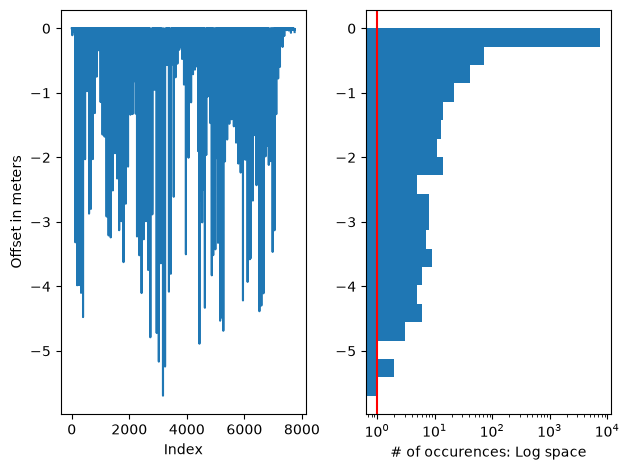

In [99]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=2, nrows=1)

axs[0].plot(diff)
axs[0].set_xlabel("Index")
axs[0].set_ylabel("Offset in meters")
axs[1].hist(diff, bins=20, orientation="horizontal")
axs[1].set_xscale("log")
axs[1].set_xlabel("# of occurences: Log space")
axs[1].axvline(1, color="red")
plt.tight_layout()

As you can see, there are only about 4 points that are >5 meters away based on using an ellipsoid vs a sphere. The vast, vast majority of points are within a meter of each other. It's also worth mentioning that these are for NRT data, so they're staggered and artificially bigger than delayed-mode or flight model data will provide.

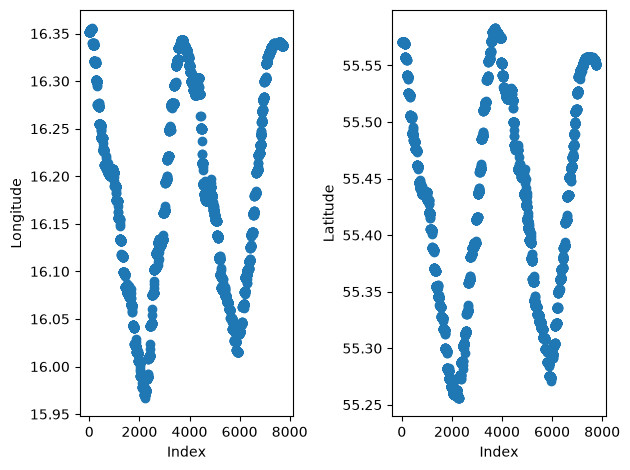

In [100]:
fig, axs = plt.subplots(ncols=2, nrows=1)
axs[0].scatter(data.N_MEASUREMENTS, data.LONGITUDE)
axs[0].set_xlabel("Index")
axs[0].set_ylabel("Longitude")
axs[1].scatter(data.N_MEASUREMENTS, data.LATITUDE)
axs[1].set_xlabel("Index")
axs[1].set_ylabel("Latitude")
plt.tight_layout()

I *think* this is a high-enough level of accuracy for all of the points. Regardless, we've tested out `gsw` and the method already in QARTOD and we should probably allow users to specify which algorithm they prefer.

Outcomes of this exploration:
* We should set hard limits on $\pm 90$ and $\pm 180$ on our `bbox`, considering it leads to potentially introducing NaNs to our products.
    * Tell the user "Must be in Geographic/signed latitude and longitude in decimal degrees.", since users could potentially be putting in 0-360/0-180, values in [DMS](https://en.wikipedia.org/wiki/Degree_(angle)#Subdivisions), or values in radians.
* We should let the user specify which method they want to use and implement `gsw` accordingly.

### Adding on-land test
The manual described "...reported postions over land..." and that immediately sounded like a QC test that exists in another toolbox, the [NOC Position on Land test](https://github.com/NOC-OBG-Autonomy/pelagos-py/blob/main/src/pelagos_py/steps/quality_control/position_on_land_qc.py). However, we probably shouldn't be adding `pelagos` as a dependency of QARTOD - QARTOD should focus on being small, reliable, and flexible. The individual steps of `pelagos` are intended to be run in a pipeline and as such, there are a lot of complexities that might arise from using it.

I'll add that the GSTPP describes this step as "Position on Land" in test #1.4.
> ... It does so by comparing the location with a file of known bathymetric values.
> 
> The test begins by checking if the latitude or longitude of the station has a quality flag set to be erroneous. If so, the next station is examined. If the position is not flagged as erroneous, then the position of the station is checked against a file of the ocean bathymetry to determine if the location is on land or not. If the station is at sea, it is examined to determine if there is a sounding and that the attached quality flag is not set to be errorneous. If there is no sounding, or if the value is flagged as erroneous, processing passees to the next station.

For more background, the GSTPP (Global Temperature-Salinity Profile Programme) describes its datasets a observations from water samplers, CTDs, thermistor chains, and thermosalinographs. Therefore, it makes sense to have terminology like "sounding" in the test. But this is done similarly to that of `pelagos`, which uses [`geopandas`'s *naturalearth*](https://geopandas.org/en/v0.8.1/reference/geopandas.datasets.get_path.html). Some alternatives:
* The [GSHHG](https://en.wikipedia.org/wiki/GSHHG) is public domain and is a vectorized map. This might be something I could load in, I haven't used it before.
    * There is a package called [`roaring-landmask`](https://pypi.org/project/roaring-landmask/) that uses this and emphasizes speed. Looks like it was done in Rust - so speed makes a lot of sesnse.
    * Installation: `roaring-landmask` takes about 101MB, just 5 packages. Might be too big?
* <s>[`Basemap`](https://matplotlib.org/basemap/stable/users/geography.html) is something I used way back when once for visualizing data. However, it isn't vectorized.</s>
    * I found a project that might not be maintained - [`global-land-mask`](https://pypi.org/project/global-land-mask/). It is really small and supposedly is a lot faster than `Basemap`.
    * `pip install global-land-mask` was only about 1.8MB.
    * Deciding *against* using this, because it is 6 years old and even `basemap` is about a year since the last release. It wants to downgrade numpy and matplotlib in my environment, which shouldn't be the case.
* There is also [`regionmask`](https://regionmask.readthedocs.io/en/stable/defined_landmask.html), which reminds me of cartopy. This uses [Natural Earth](https://www.naturalearthdata.com/), like how Geopandas does.
    * This was about 33MB split across 36 packages - not sure if this would be preferred over `roaring-landmask`.

So let's try out `roaring-landmask`, `global-land-mask`, and `regionmask` (note that `glm` installs with pip).

#### roaring-landmask
When using `.contains_many`, I specify longitude, then latitude.

In [101]:
#   Re-import my data, if I need it.
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

data_path = "/home/aaron-mau/Code/gsoc/SEA063_20231113T1357_R.nc"
data = xr.load_dataset(data_path)

In [102]:
#   The example given by the developers
from roaring_landmask import RoaringLandmask

l = RoaringLandmask.new()
x = np.arange(-180, 180, .5)
y = np.arange(-90, 90, .5)

xx, yy = np.meshgrid(x,y)

print ("points:", len(xx.ravel()))
on_land = l.contains_many(xx.ravel(), yy.ravel())

points: 259200


In [103]:
on_land.sum()

np.int64(88115)

In [104]:
xx, yy = np.meshgrid(data.LONGITUDE, data.LATITUDE)
on_land = l.contains_many(xx.ravel(), yy.ravel())

##### Small note on magic functions
If you have `ipython`, then you have access to some so-called "[magic functions](https://ipython.readthedocs.io/en/stable/interactive/magics.html)" that you can run in a cell. These allow you to do some shell-style commands specific to a single cell of a Jupyter notebook. You can call them using `%%` and there are lots of them ([summarized well here](https://www.python4data.science/en/24.3.0/workspace/ipython/magics.html)).

I make a lot of use of %%time and %%timeit. %%time is great for a single line (kind of like in-line timing) and %%timeit will do the whole cell over and over again to get a good estimate of how long a process or function needs.

In [106]:
%%time
on_land = l.contains_many(xx.ravel(), yy.ravel())   #   Now while timing it

CPU times: user 1.43 s, sys: 25.7 ms, total: 1.45 s
Wall time: 1.44 s


In [107]:
print(f"Number of points detected on land: {on_land.sum()}")

Number of points detected on land: 0


In [108]:
print(len(data.LONGITUDE))
print(len(on_land))
print(on_land)  #   Boolean array of the mesh

7749
60047001
[False False False ... False False False]


Neat, this is essentially the result we'd want. It's a boolean array for all lat/lon. Not sure why the dimensions are so weird, though. *Update*: It's because the meshgrid has tied lat and lon together.

We don't expect any of the data points to be on land, so let's confirm that we're doing it right (and also see the bounds).

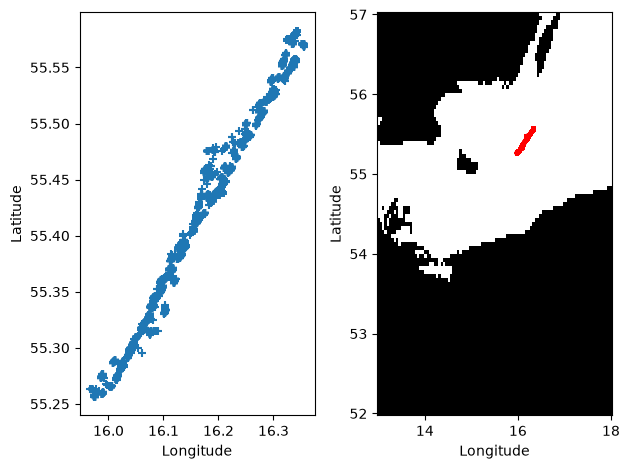

In [109]:
point_density = 100
lons = np.linspace(13, 18, point_density)
lats = np.linspace(52, 57, point_density)
xx, yy = np.meshgrid(lons, lats)
land = l.contains_many(xx.ravel(), yy.ravel()).reshape(xx.shape)

fig, axs = plt.subplots(nrows=1, ncols=2)
axs[0].scatter(data.LONGITUDE, data.LATITUDE, marker="+")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
axs[1].pcolormesh(xx, yy, land, shading="nearest", cmap="Greys")
axs[1].scatter(data.LONGITUDE, data.LATITUDE, c="red", s=5, marker="+")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")
plt.tight_layout()

Okay, this looks bad. This is really crusty looking - that's the case for a bitmap. It isn't really *meant* to be visualized, so I'm pulling all the points in as "land" in the plot above. It gets less crusty if I turn up the `point_density`.

However, the package says that points close to the shore are checked against the vector shapes of the coastline. This suggests that it's even higher resolution that I'd otherwise be doing.

Because my data is clearly far from land and already worked just fine, let's fake it being bad.

In [110]:
#   Note: This takes ages with the meshgrid. No idea why it's 10x what it was before.
bad_lat = data.LATITUDE.to_numpy() - 1.3  #   Shifts the latitude down to 54 N, right by the Polish coastline.
bad_lon = data.LONGITUDE.to_numpy() - 1 #   Moves it west, making it easier to see the intersection with the coast.

xx_bad, yy_bad = np.meshgrid(bad_lon, bad_lat)
bad_land = l.contains_many(xx_bad.ravel(), yy_bad.ravel())

In [111]:
print(f"{bad_land.sum().item()} of {len(bad_land)}: {100 * (bad_land.sum().item() / len(bad_land)):.2f}%")  #   This says about half of them are bad now that we've shoved it down into the coastline of Poland.

27977455 of 60047001: 46.59%


So now let's downscale this a bit and look at how this "resolution" works. It's all using a bitmap, so we should see *exactly* where this hidden vector shows up.

In [112]:
#   Not going to do the meshgrid, since we just want the points themselves and corresponding flags
landmask = RoaringLandmask.new()    #   Define it once.
def land_mask(lon, lat):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    flag_arr = np.ma.ones(lon.size, dtype="uint8") #   Init to flag 1 "good"
    
    on_land = landmask.contains_many(lon, lat)
    flag_arr.mask = on_land
    flag_arr[flag_arr.mask] = 4
    return flag_arr
flags = land_mask(lon=bad_lon, lat=bad_lat)
print(len(flags[flags == 4]))
print(len(flags))

3551
7749


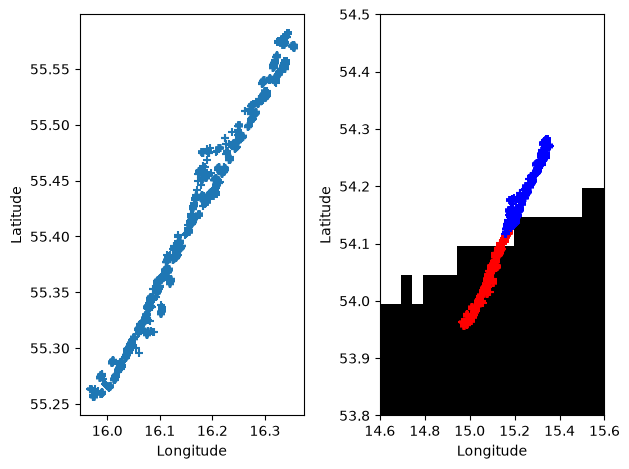

In [113]:
fig, axs = plt.subplots(nrows=1, ncols=2)
axs[0].scatter(data.LONGITUDE, data.LATITUDE, marker="+")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
axs[1].pcolormesh(xx, yy, land, shading="nearest", cmap="Greys")
# axs[1].scatter(bad_lon, bad_lat, c="red", s=5, marker="+")
axs[1].scatter(bad_lon[flags == 4], bad_lat[flags == 4], c="red", marker="+")
axs[1].scatter(bad_lon[flags == 1], bad_lat[flags == 1], c="blue", marker="+")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")
axs[1].set_ylim([53.8, 54.5])
axs[1].set_xlim([14.6, 15.6])
plt.tight_layout()

So here we can see how the "blockiness" of the bitmap doesn't quite align with where the vector is going. Note how the red line starts above the shaded coastline region.

With a very fine point density, we can approach what the vector looks like that `RoaringLandmask` is pulling from.

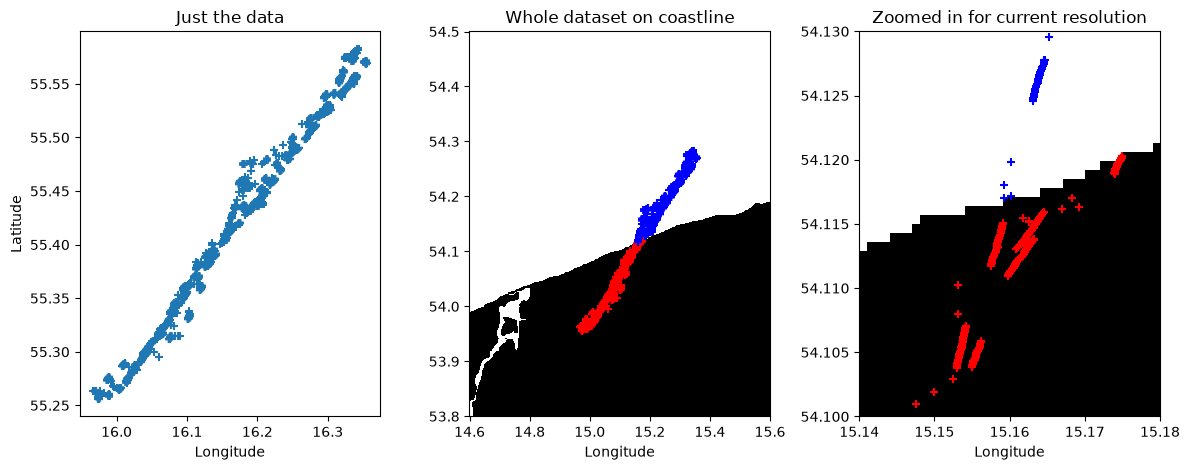

In [114]:
point_density = 1000
lons = np.linspace(14.6, 15.6, point_density)
lats = np.linspace(53.8, 54.5, point_density)
xx, yy = np.meshgrid(lons, lats)
land = l.contains_many(xx.ravel(), yy.ravel()).reshape(xx.shape)
fig, axs = plt.subplots(nrows=1, ncols=3)
axs[0].scatter(data.LONGITUDE, data.LATITUDE, marker="+")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
axs[0].set_title("Just the data")
axs[1].pcolormesh(xx, yy, land, shading="nearest", cmap="Greys")
# axs[1].scatter(bad_lon, bad_lat, c="red", s=5, marker="+")
axs[1].scatter(bad_lon[flags == 4], bad_lat[flags == 4], c="red", marker="+")
axs[1].scatter(bad_lon[flags == 1], bad_lat[flags == 1], c="blue", marker="+")
axs[1].set_xlabel("Longitude")
axs[1].set_title("Whole dataset on coastline")
#   And now to zoom waaaaaay in
axs[2].pcolormesh(xx, yy, land, shading="nearest", cmap="Greys")
axs[2].scatter(bad_lon[flags == 4], bad_lat[flags == 4], c="red", marker="+")
axs[2].scatter(bad_lon[flags == 1], bad_lat[flags == 1], c="blue", marker="+")
axs[2].set_xlabel("Longitude")
axs[2].set_ylim([54.10, 54.13])
axs[2].set_xlim([15.14, 15.18])
axs[2].set_title("Zoomed in for current resolution")
fig.set_figwidth(12)
plt.tight_layout()

In [117]:
%%time
landmask = RoaringLandmask.new()    #   Define it once.
def land_mask(lon, lat):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    flag_arr = np.ma.ones(lon.size, dtype="uint8") #   Init to flag 1 "good"
    
    on_land = landmask.contains_many(lon, lat)
    flag_arr.mask = on_land
    flag_arr[flag_arr.mask] = 4
    return flag_arr
flags = land_mask(lon=data.LONGITUDE, lat=data.LATITUDE)

CPU times: user 1.96 s, sys: 56.1 ms, total: 2.01 s
Wall time: 2 s


So that method works well. Checking for points on land and assigning the flags takes about 3 seconds, which is probably pretty good considering we don't have to actually download anything (user doesn't have to specify "give me 110m resolution" or whatever).

#### regionmask
This was updated two days ago and has `dependabot` and `pre-commit` implemented. That's reassuring.

In [118]:
import regionmask
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110 #   1:110 scales

<GeoAxes: >

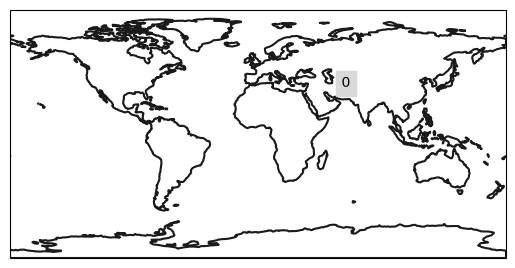

In [119]:
land.plot() #   You need cartopy installed to run this

In [120]:
print(dir(land))    #   Learning about the object we just got. Most of the tutorials refer to the "mask" attribute.

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_display', '_region_ids', 'abbrevs', 'bounds', 'bounds_global', 'centroids', 'coords', 'from_geodataframe', 'lon_180', 'lon_360', 'map_keys', 'mask', 'mask_3D', 'mask_3D_frac_approx', 'name', 'names', 'numbers', 'overlap', 'plot', 'plot_regions', 'polygons', 'region_ids', 'regions', 'source', 'to_dataframe', 'to_geodataframe', 'to_geoseries']


In [121]:
help(land.mask)

Help on method mask in module regionmask.core.regions:

mask(
    lon_or_obj: np.typing.ArrayLike | xr.DataArray | xr.Dataset,
    lat: np.typing.ArrayLike | xr.DataArray | None = None,
    *,
    method=None,
    wrap_lon: None | bool | Literal[180, 360] = None,
    flag: Literal['abbrevs', 'names'] | None = 'abbrevs',
    use_cf: bool | None = None
) -> xr.DataArray method of regionmask.core.regions.Regions instance
    create a 2D float mask of a set of regions for the given lat/ lon grid

    Parameters
    ----------
    lon_or_obj : object or array_like
        Can either be a longitude array and then ``lat`` needs to be
        given. Or an object where the longitude and latitude can be
        retrieved from, either using cf_xarray or by the names "lon"
        and "lat". See also ``use_cf``.

    lat : array_like, optional
        If ``lon_or_obj`` is a longitude array, the latitude needs to be
        passed.

    wrap_lon : None | bool | 180 | 360, default: None
        Whet

When I passed `bad_lon` and `bad_lat` into the mask, I would get errors that they were the same size. I think it's meant to be using Xarray a lot more, because `data.LONGITUDE` and `data.LATITUDE` seem to work fine when plugged in.

```python
x = land.mask(bad_lon, bad_lat).notnull().values

...
File ~/miniforge3/envs/gsoc/lib/python3.14/site-packages/regionmask/core/utils.py:110, in _wrapAngle(lon, wrap_lon, is_unstructured)
    108 if lon_.ndim == 1 and not is_unstructured:
    109     if lon_.shape != np.unique(lon_).shape:
--> 110         raise ValueError("There are equal longitude coordinates (when wrapped)!")
    112 return lon_

ValueError: There are equal longitude coordinates (when wrapped)!
```

Normally when we define a function we start with `asarray`, but in this case we'll want to convert it to an Xarray object with some kind of dimension.

In [122]:
blon = xr.DataArray(np.asarray(bad_lon), dims="N_MEASUREMENTS")
blat = xr.DataArray(np.asarray(bad_lat), dims="N_MEASUREMENTS")
x = land.mask(blon, blat).notnull().values
any(x == True)

True

In [123]:
x = land.mask(data.LONGITUDE, data.LATITUDE)
any(x == True)

/tmp/ipykernel_183378/2895183286.py:1: UserWarning: No gridpoint belongs to any region. Returning an all-NaN mask.
  x = land.mask(data.LONGITUDE, data.LATITUDE)


False

It looks like, if everything is good and there are no points on land, it gives a warning that the data are not a point in the current region.

In the preexisting location test, we filtered warnings like this using `warnings.simplefilter("ignore")`. Maybe we can use that here?

In [124]:
import warnings
def regionmask_landmask(lon, lat, res="low"):
    if res == "low":
        land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
    elif res == "med":
        land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
    elif res == "hi":
        land = regionmask.defined_regions.natural_earth_v5_0_0.land_10
    lon = xr.DataArray(np.asarray(lon), dims="N_MEASUREMENTS")
    lat = xr.DataArray(np.asarray(lat), dims="N_MEASUREMENTS")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        on_land = land.mask(lon, lat).notnull().values

    flags = np.ones(lon.size, dtype="uint8")
    flags[on_land] = 4

    return flags
flags = regionmask_landmask(bad_lon, bad_lat)

Now that I've got it defined, let's run it at different resolutions. The vectorized version had 3551 flagged points.

Note that the first time I ran this, I needed to download the data to the cache. It didn't take as long on subsequent runs.

In [125]:
flags1 = regionmask_landmask(bad_lon, bad_lat, res="low")   #   Default - lowest resolution

print(len(flags1[flags1 == 4]))
print(len(flags1))

4879
7749


In [126]:
flags2 = regionmask_landmask(bad_lon, bad_lat, res="med")

print(len(flags2[flags2 == 4]))
print(len(flags2))

3360
7749


/tmp/ipykernel_183378/1235841413.py:6: UserWarning: `land_50` of `natural_earth_v4_1_0` and `natural_earth_v5_0_0` does not quite extend to 90°S - it's recommended to use `natural_earth_v5_1_2` instead. See https://github.com/regionmask/regionmask/issues/487
  land = regionmask.defined_regions.natural_earth_v5_0_0.land_50


In [127]:
flags3 = regionmask_landmask(bad_lon, bad_lat, res="hi")

print(len(flags3[flags3 == 4]))
print(len(flags3))

3274
7749


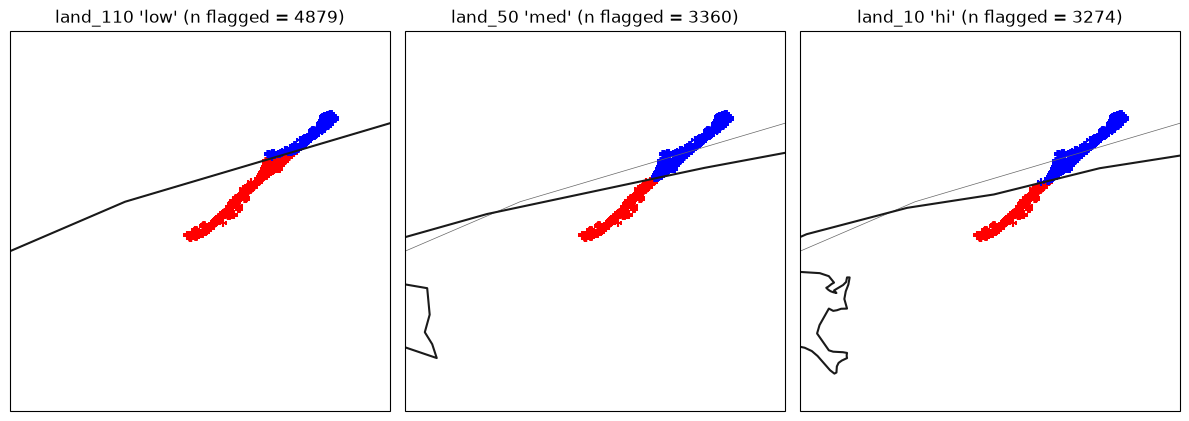

In [128]:
import cartopy.crs as ccrs
fig, axs = plt.subplots(nrows=1, ncols=3, subplot_kw={"projection": ccrs.PlateCarree()})
zoom_y = [53.5, 54.5]
zoom_x = [14.5, 15.5]
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land.plot(ax=axs[0])
axs[0].scatter(bad_lon[flags1 == 4], bad_lat[flags1 == 4], c="red", marker="+")
axs[0].scatter(bad_lon[flags1 == 1], bad_lat[flags1 == 1], c="blue", marker="+")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")
axs[0].set_ylim(zoom_y)
axs[0].set_xlim(zoom_x)
axs[0].set_title(f"land_110 'low' (n flagged = {len(flags1[flags1 == 4])})")

land = regionmask.defined_regions.natural_earth_v5_0_0.land_50
land.plot(ax=axs[1])
axs[1].scatter(bad_lon[flags2 == 4], bad_lat[flags2 == 4], c="red", marker="+")
axs[1].scatter(bad_lon[flags2 == 1], bad_lat[flags2 == 1], c="blue", marker="+")
axs[1].set_xlabel("Longitude")
axs[1].set_ylim(zoom_y)
axs[1].set_xlim(zoom_x)
axs[1].set_title(f"land_50 'med' (n flagged = {len(flags2[flags2 == 4])})")

land = regionmask.defined_regions.natural_earth_v5_0_0.land_10
land.plot(ax=axs[2])
axs[2].scatter(bad_lon[flags3 == 4], bad_lat[flags3 == 4], c="red", marker="+")
axs[2].scatter(bad_lon[flags3 == 1], bad_lat[flags3 == 1], c="blue", marker="+")
axs[2].set_xlabel("Longitude")
axs[2].set_ylim(zoom_y)
axs[2].set_xlim(zoom_x)
axs[2].set_title(f"land_10 'hi' (n flagged = {len(flags3[flags3 == 4])})")
fig.set_figwidth(12)
plt.tight_layout()

So now we can see some of the accuracy that the user can get.

In [129]:
%%time
flags = regionmask_landmask(data.LONGITUDE.values, data.LATITUDE.values, res="hi")
# flags = regionmask_landmask(bad_lon, bad_lat, res="hi")

CPU times: user 32.3 ms, sys: 0 ns, total: 32.3 ms
Wall time: 31.6 ms


#### End decision
Probably go with `regionmask`? Let's overlay what the vector looks like when compared the to `hi` setting.

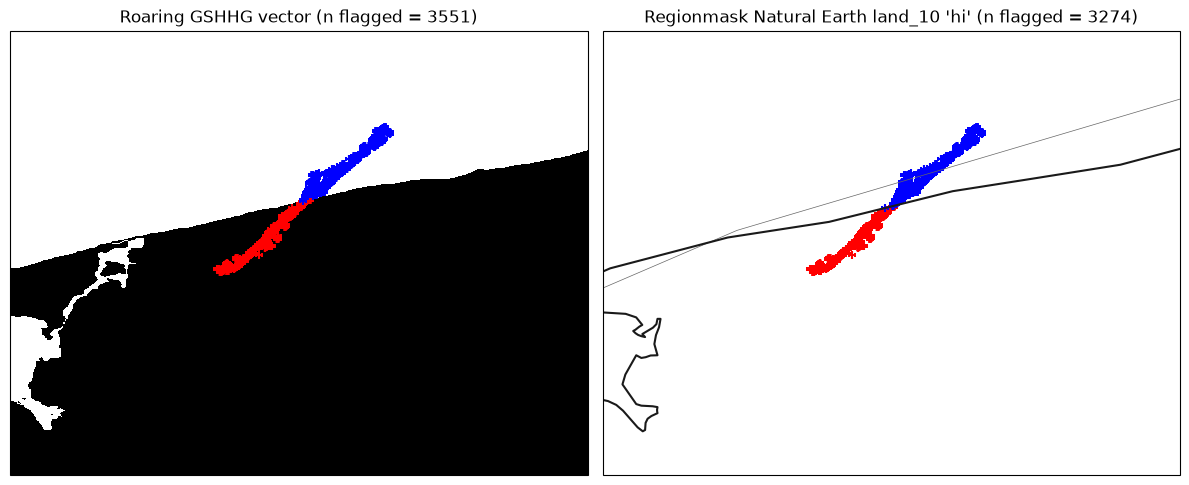

In [130]:
flags_roaring = land_mask(bad_lon, bad_lat)
flags_regionmask = regionmask_landmask(bad_lon, bad_lat, res="hi")

point_density = 1000
zoom_y = [53.5, 54.5]
zoom_x = [14.5, 15.8]
lons = np.linspace(zoom_x[0], zoom_x[1], point_density)
lats = np.linspace(zoom_y[0], zoom_y[1], point_density)
xx, yy = np.meshgrid(lons, lats)
land = l.contains_many(xx.ravel(), yy.ravel()).reshape(xx.shape)

fig, axs = plt.subplots(nrows=1, ncols=2, subplot_kw={"projection": ccrs.PlateCarree()})

axs[0].pcolormesh(xx, yy, land, shading="nearest", cmap="Greys")
axs[0].scatter(bad_lon[flags_roaring == 4], bad_lat[flags_roaring == 4], c="red", marker="+")
axs[0].scatter(bad_lon[flags_roaring == 1], bad_lat[flags_roaring == 1], c="blue", marker="+")
axs[0].set_xlabel("Longitude")
axs[0].set_ylim(zoom_y)
axs[0].set_xlim(zoom_x)
axs[0].set_title(f"Roaring GSHHG vector (n flagged = {len(flags_roaring[flags_roaring == 4])})")

land = regionmask.defined_regions.natural_earth_v5_0_0.land_10
land.plot(ax=axs[1])
axs[1].scatter(bad_lon[flags_regionmask == 4], bad_lat[flags_regionmask == 4], c="red", marker="+")
axs[1].scatter(bad_lon[flags_regionmask == 1], bad_lat[flags_regionmask == 1], c="blue", marker="+")
axs[1].set_xlabel("Longitude")
axs[1].set_ylim(zoom_y)
axs[1].set_xlim(zoom_x)
axs[1].set_title(f"Regionmask Natural Earth land_10 'hi' (n flagged = {len(flags_regionmask[flags_regionmask == 4])})")
fig.set_figwidth(12)
plt.tight_layout()

In [131]:
%%timeit
flags_roaring = land_mask(bad_lon, bad_lat)

3.05 ms ± 25.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [132]:
%%timeit
flags_regionmask = regionmask_landmask(bad_lon, bad_lat, res="hi")

28.4 ms ± 498 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


I take it back, it seems like the roaring resolution is higher. Obviously, you can see the Polish estuary near [Dziwnów](https://maps.app.goo.gl/rVd7rex6RCusS7nt8) on this one and you can make out more of the bumpiness of the coastline. I changed the x-lim to end at 15.8 so that way you can see the nub around [Kołobrzeg](https://maps.app.goo.gl/DH7wsJpmFRzzPDNS6). If you're working with coastal gliders, you probably want the option on the left.

Just now when running it again with %%timeit, it seems like the roaring test is actually faster than when I was testing it before. I'm not quite sure why this is, but regardless, it seems like performance is not as bad as I thought it was before (where the roaring method took 20 seconds for some reason).

Given that both methods are relatively fast (with `roaring` being marginally faster), but `roaring` having the higher resolution on the coastline for flagging purposes, I'd argue that `roaring` is what we should implement. The only caveat is that it's a big install to your environment - approx. 3x the size of the alternative.